# Unveiling the Semantic Distance in E-Commerce Reviews: A Deep Learning Approach

## Introduction & Objectives

In the realm of Natural Language Processing (NLP), sentiment analysis is often treated as a straightforward categorization task (e.g., positive vs. negative). However, human language and sentiment are rarely binary. When dealing with ordinal ratings—such as the 1 to 5-star review system—a fascinating question arises: **Is the semantic gap between a 1-star and a 2-star review mathematically and linguistically equivalent to the gap between a 3-star and a 4-star review?** This notebook aims to explore this underlying semantic relationship using the [Olist Brazilian E-commerce Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). Beyond merely fulfilling a classification task, this project serves as a comprehensive, end-to-end sandbox for exploring Deep Learning techniques from scratch. 

### Key Goals:
1. **Model Progression:** We will start by training traditional Recurrent Neural Networks (RNNs/LSTMs) from scratch to establish a strong baseline.
2. **Hyperparameter Tuning:** We will implement intelligent search strategies to optimize our baseline architecture.
3. **State-of-the-Art Fine-Tuning:** We will leverage Transfer Learning by fine-tuning pre-trained Transformer models (comparing English/Multilingual models with native Portuguese models) to see how deep contextual embeddings understand our data.
4. **Experiment Tracking:** Every model, parameter, and metric will be tracked and logged using **MLflow**.
5. **Semantic Analysis:** Ultimately, by analyzing the outputs our best-performing models, we will attempt to decode the semantic boundaries between different star ratings.

Let's begin by preparing our environment and exploring the data.

In [1]:
import os
import re
import shutil
from collections import Counter
from pathlib import Path

import kagglehub
import pandas as pd
import torch

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
MLFLOW_DIR = Path("../mlflow").resolve()
EXPERIMENT_NAME = "Olist_Review_Classification"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


Mlflow setup:

In [2]:
%%capture
import mlflow
os.makedirs(MLFLOW_DIR, exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{(MLFLOW_DIR / 'mlflow.db').as_posix()}")
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    mlflow.create_experiment(name=EXPERIMENT_NAME, artifact_location=(MLFLOW_DIR / "artifacts").as_uri())
mlflow.set_experiment(EXPERIMENT_NAME)

## 1. Data Preparation

In [3]:
data_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
shutil.copytree(data_path, "../data", dirs_exist_ok=True)

df = pd.read_csv("../data/olist_order_reviews_dataset.csv")
print(df.shape)
df.head(10)

(99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


In [4]:
df.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [5]:
# now let's drop the nulls for the variable review_comment_message
# and leave only this column plus the target variable review_score

df = df.dropna(subset=['review_comment_message'])
df = df[['review_comment_message', 'review_score']]
print(df.shape)
df.head(5)

(40977, 2)


,review_comment_message,review_score
3,Recebi bem antes do prazo estipulado.,5
4,Parabéns lojas lannister adorei comprar pela I...,5
9,aparelho eficiente. no site a marca do aparelh...,4
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4
15,"Vendedor confiável, produto ok e entrega antes...",5


In [6]:
# we'll check the distribution of the target variable review_score
df['review_score'].value_counts()

review_score
5    20554
1     8745
4     5976
3     3557
2     2145
Name: count, dtype: int64

As seen above, our dataset is heavily imbalanced. Instead of using class weights, we'll use undersampling.

This simplifies the comparison between different architectures, since we don't need to tune class weights for each model. 

Although we lose some data and potentially some performance, our goal is not to build the best possible classifier. A balanced dataset gives us a fair and unbiased baseline for analyzing how the models confuse the different review ratings.

In [7]:
min_class_size = df['review_score'].value_counts().min()
df_balanced = df.groupby('review_score').sample(n=min_class_size, random_state=RANDOM_STATE)
df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(df_balanced.shape)
print(df_balanced['review_score'].value_counts())

(10725, 2)
review_score
1    2145
2    2145
4    2145
5    2145
3    2145
Name: count, dtype: int64


Now it's a good moment to define a function to deal with special characters, so that we handle the train/test data and also prepare for its reuse for single-string predictions later.

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-záéíóúâêôãõç\s]', '', text) 
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_balanced['review_comment_message'] = df_balanced['review_comment_message'].apply(clean_text)

In [9]:
# split into train (70%), val (15%), and test (15%)

X = df_balanced['review_comment_message'].values
y = df_balanced['review_score'].values - 1 # shift to 0-indexed labels for output layer vector format

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y # perfect balance
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")

for n, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    pd.DataFrame({"review_comment_message": X, "review_score": y + 1}).to_csv(f"../data/{n}.csv", index=False)

Train size: 7507 | Val size: 1609 | Test size: 1609


## 2. Evaluation Metrics

The central objective of this project extends beyond maximizing classification performance. Rather than treating review scores as independent categories, we investigate whether the semantic relationships learned by different models preserve the natural ordinal structure of customer ratings. To support this analysis, our evaluation protocol is organized into four complementary groups of metrics.

---

### 2.1 Target Optimization Metric

**Macro F1-Score** is adopted as the primary optimization metric throughout this notebook.

Macro F1 computes the F1-score independently for each rating and averages them without considering class frequency. This prevents the model from achieving high performance by focusing only on the most common ratings and encourages balanced learning across the entire 1-to-5 star spectrum. All hyperparameter tuning and model selection procedures will therefore optimize Macro F1.

---

### 2.2 Standard Classification Metrics

Although this study focuses on semantic relationships between ratings, traditional classification metrics remain essential to quantify predictive performance.
For every experiment we compute:

- **Accuracy** – overall prediction accuracy.
- **Macro F1-Score** – balanced performance across all classes.
- **Class-wise F1-Scores** – individual performance for each rating.

---

### 2.3 Ordinal Metrics

Customer ratings possess an inherent ordering. Misclassifying a 5-star review as 4 stars is substantially different from predicting it as 1 star.
To account for this ordinal structure, we additionally compute:

- **Mean Absolute Error (MAE)** – average prediction distance measured in rating levels.
- **Root Mean Squared Error (RMSE)** – emphasizes larger ordinal mistakes by squaring prediction errors.
- **Quadratic Weighted Cohen's Kappa (QWK)** – measures agreement while penalizing disagreements according to their ordinal distance.

These metrics complement traditional classification measures by incorporating the ordered nature of review scores.

It is important to note that QWK assumes uniformly spaced rating levels and applies a quadratic penalty as prediction distance increases. Consequently, QWK should be interpreted as an ordinal performance metric rather than direct evidence of semantic distance.

---

### 2.4 Semantic Distance Analysis

The primary scientific question addressed by this notebook is whether adjacent ratings are semantically closer than distant ones.

Instead of relying solely on aggregate metrics, we perform two descriptive analyses derived from the prediction errors:

- **Mean Error Distance per Class** – quantifies how many rating levels, on average, each true class is displaced by the model.
- **Error Distance Distribution** – measures how prediction errors are distributed across ordinal distances (0, 1, 2, ... rating levels).

Together with the confusion matrix, these analyses help characterize whether model errors remain concentrated among neighboring ratings or frequently jump across distant sentiment levels.

---

### 2.5 Artifacts Logged with MLflow

To ensure complete experiment reproducibility, every MLflow run stores:

- all evaluation metrics;
- the confusion matrix visualization;
- the prediction file (`y_true`, `y_pred`).

Persisting predictions enables future computation of additional metrics without requiring model retraining.

In [10]:
# The evaluation method explained above is implemented in the object below

from utils.evaluation import MetricsEvaluator, EvaluationPhase
print("EvaluationPhase:", list(EvaluationPhase))
evaluator = MetricsEvaluator()

# Main use throughout the project during any mlflow run:
# evaluator.evaluate("Model Name", y_true, y_pred)


EvaluationPhase: [<EvaluationPhase.VALIDATION: 'Validation Data'>, <EvaluationPhase.TEST: 'Test Data'>]


## 3. Baseline RNN Model

For our baseline architecture, we will build a RNN.

Before feeding the cleaned train text into the network, we need to build a numerical vocabulary and create batch loaders.

### 3.1 Vocabulary Building (word-based tokenization)
We map the most frequent words to unique integers. **Crucial:** The vocabulary is built strictly on the training set to prevent data leakage from the validation/test sets.

In [11]:
def build_vocab(texts, max_words=10000):
    counter = Counter()
    for text in texts:
        counter.update(text.split())
    
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in counter.most_common(max_words - 2):
        vocab[word] = len(vocab)
    return vocab

print("Building vocabulary...")
vocab = build_vocab(X_train, max_words=10000)
print(f"Vocabulary size: {len(vocab)} words")
print("Sample words from vocabulary:", list(vocab.keys())[:15])

Building vocabulary...
Vocabulary size: 7534 words
Sample words from vocabulary: ['<PAD>', '<UNK>', 'o', 'produto', 'e', 'a', 'não', 'de', 'do', 'que', 'com', 'recebi', 'prazo', 'um', 'muito']


In [12]:
# let's also check the distribution of the number of words so that we can choose a correct max_len for the model
df["review_comment_message"].str.split().str.len().describe()

count    40977.000000
mean        11.679210
std          9.554347
min          0.000000
25%          4.000000
50%          9.000000
75%         16.000000
max         45.000000
Name: review_comment_message, dtype: float64

The longest review in the dataset contains only 45 tokens, so we can safely set max_len to 50 to accommodate all reviews without truncation

### 3.2 Sequence Formatting & DataLoaders
We'll convert the texts into fixed-length integer sequences (padding short ones, truncating long ones).

In [13]:
MAX_LEN = 50

def text_to_seq(text, vocab, max_len=MAX_LEN):
    tokens = text.split()
    seq = [vocab.get(word, vocab['<UNK>']) for word in tokens]
    if len(seq) < max_len:
        seq = seq + [vocab['<PAD>']] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

Thus we are able to wrap these sequences in PyTorch `DataLoader` objects for batch processing, while we also integrate knowledge of its preprocessing steps.

In [14]:
from torch.utils.data import DataLoader, Dataset
from dataclasses import dataclass

@dataclass(slots=True)
class TextPreprocessor:
    vocab: dict[str, int]
    max_len: int

    @classmethod
    def build(cls, texts, max_len: int = 50, max_vocab_size: int = 10000) -> "TextPreprocessor":
        vocab = build_vocab(texts, max_vocab_size) # as we're in a notebook context, it's appropriate to use the build_vocab function defined above
        return cls(vocab=vocab, max_len=max_len)

    def encode(self, text: str) -> list[int]:
        return text_to_seq(text, self.vocab, self.max_len) # same as commented above

    def to_dict(self) -> dict:
        return {
            "vocab": self.vocab,
            "max_len": self.max_len,
        }
    
class ReviewDataset(Dataset):
    def __init__(self, X, y, preprocessor: TextPreprocessor):
        self.X = [preprocessor.encode(text) for text in X]
        self.y = y
        
    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.tensor(self.X[idx], dtype=torch.long), torch.tensor(self.y[idx], dtype=torch.long)

preprocessor = TextPreprocessor.build(X_train, max_len=MAX_LEN, max_vocab_size=10000)

Finally, let's create the DataLoaders for training, validation, and testing with a default batch size of 64.

In [15]:
BATCH_SIZE = 64

train_loader = DataLoader(ReviewDataset(X_train, y_train, preprocessor), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ReviewDataset(X_val, y_val, preprocessor), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ReviewDataset(X_test, y_test, preprocessor), batch_size=BATCH_SIZE, shuffle=False)

sample_x, sample_y = next(iter(train_loader))
print(f"Batch X shape: {sample_x.shape} | Batch y shape: {sample_y.shape}")

Batch X shape: torch.Size([64, 50]) | Batch y shape: torch.Size([64])


### 3.3 The Model Architecture (Bidirectional LSTM)
Our baseline model consists of three main components:
1. **Embedding Layer:** Converts our word indices into dense vectors of fixed size. We pass `padding_idx=0` so the network learns to ignore our `<PAD>` tokens.
2. **LSTM Layer:** A Bidirectional Long Short-Term Memory layer that reads the sequence from left-to-right and right-to-left, capturing contextual dependencies.
3. **Linear Layer:** The final fully-connected layer that maps the LSTM's output to our 5 distinct classes.

Classic references on LSTM:
- Gers, F. A., Schmidhuber, J., & Cummins, F. (2000). *Learning to Forget: Continual Prediction with LSTM*. Neural Computation, 12(10), 2451–2471. [[PDF](https://www.researchgate.net/publication/271459628_Learning_to_forget_continual_prediction_with_LSTM)]
- Hochreiter, S., & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation, 9(8), 1735–1780. [[PDF](https://www.researchgate.net/publication/13853244_Long_Short-Term_Memory)]
- Sutskever, I., Vinyals, O., & Le, Q. V. (2014). *Sequence to Sequence Learning with Neural Networks*. In *Advances in Neural Information Processing Systems (NeurIPS 27)*, 3104–3112. [[PDF](https://papers.neurips.cc/paper/5346-sequence-to-sequence-learning-with-neural-networks.pdf)]

BiLSTM intuition:
<div align="center">

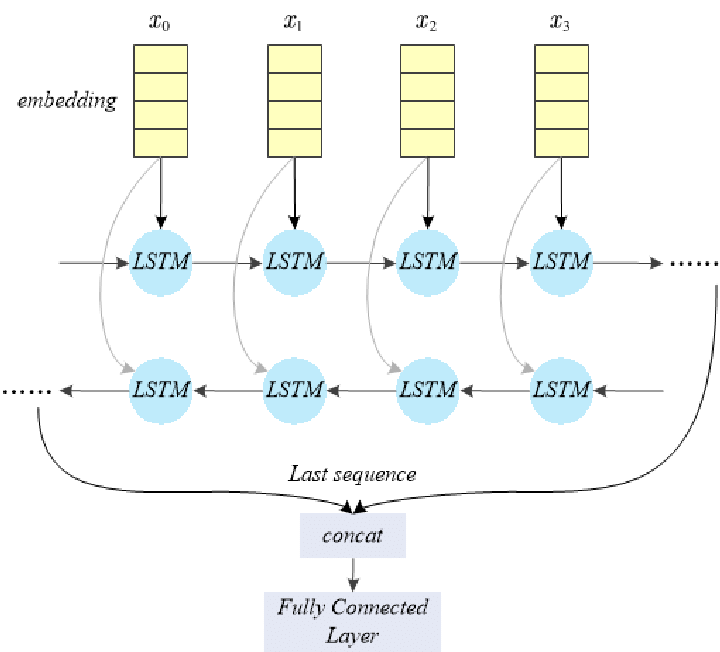

*Architecture of the Bidirectional LSTM classifier. Copied from **The Study on the Text Classification for Financial News Based on Partial Information** (IEEE Access, 2020). DOI: 10.1109/ACCESS.2020.2997969. Licensed under CC BY 4.0.*

</div>

In [16]:
import torch.nn as nn
from torch import Tensor
from torch.nn.utils.rnn import pack_padded_sequence #, pad_packed_sequence

class SentimentLSTM(nn.Module):
    """Bidirectional LSTM for sentiment classification from text."""

    def __init__(self, vocab_size: int, embedding_dim: int, hidden_dim: int, num_classes: int, dropout: float = 0.3, padding_idx: int = 0) -> None:

        super(SentimentLSTM, self).__init__()
        self.padding_idx: int = padding_idx
        self.embedding: nn.Embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx) # 1. Embedding Layer
        self.lstm: nn.LSTM = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True) # 2. Bidirectional LSTM
        self.dropout: nn.Dropout = nn.Dropout(dropout) # Dropout for regularization
        self.fc: nn.Linear = nn.Linear(hidden_dim * 2, num_classes) # 3. Fully Connected Layer
 
    def forward(self, x: Tensor) -> Tensor:
        """Runs the model's forward pass."""

        lengths: Tensor = (x != self.padding_idx).sum(dim=1) # compute the real length of each sequence in the batch
        lengths = lengths.clamp(min=1)
        embedded: Tensor = self.embedding(x)

        # Pack the sequence before feeding it into the LSTM while skipping padding internally
        packed_embedded = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, (hidden, cell) = self.lstm(packed_embedded)
        # Unpacking for attention: lstm_out, out_lengths = pad_packed_sequence(packed_output, batch_first=True)

        # Concatenate the last forward and backward hidden states
        # hidden[-2] -> last layer, forward direction; hidden[-1] -> last layer, backward direction
        hidden_cat: Tensor = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)

        dropped: Tensor = self.dropout(hidden_cat)
        out: Tensor = self.fc(dropped)
        return out
    
    def export_config(self) -> dict:
        """Returns the model's configuration as a dictionary."""
        return {
            "vocab_size": self.embedding.num_embeddings,
            "embedding_dim": self.embedding.embedding_dim,
            "hidden_dim": self.lstm.hidden_size,
            "num_classes": self.fc.out_features,
            "padding_idx": self.padding_idx
        }

### 3.4 Training Loop

It will be useful to collect every hyperparameter that governs how a model is trained into a single dataclass.

Specially aware to the possibility that the LSTM results in gradient explosion, where large error gradients accumulate during backpropagation through time, we include gradient clipping (grad_clip_norm), which caps the gradients at a maximum threshold. We also configure weight decay (L2 regularization) and set up early stopping to halt training if our validation metric stops improving.

In [17]:
from dataclasses import dataclass
from utils.training import OptimizerType, MonitorMetric

print("OptimizerType:", list(OptimizerType))
print("MonitorMetric:", list(MonitorMetric))

@dataclass
class TrainingConfig:
    epochs: int = 30
    learning_rate: float = 1e-3
    weight_decay: float = 1e-2
    optimizer: OptimizerType = OptimizerType.ADAMW
    grad_clip_norm: float | None = 5.0
    monitor_metric: MonitorMetric = MonitorMetric.F1_MACRO
    early_stopping_patience: int = 5


OptimizerType: [<OptimizerType.ADAM: 'adam'>, <OptimizerType.ADAMW: 'adamw'>, <OptimizerType.SGD: 'sgd'>]
MonitorMetric: [<MonitorMetric.VAL_LOSS: 'val_loss'>, <MonitorMetric.ACCURACY: 'accuracy'>, <MonitorMetric.F1_MACRO: 'f1_macro'>, <MonitorMetric.QWK: 'qwk'>]


With the configuration set, we can build the training loop. The PyTorch neural network training cycle requires a specific sequence of operations for each batch:

1. **Zeroing gradients**: `optimizer.zero_grad()` clears old gradients from the previous step so they don't accumulate.
2. **Forward pass**: We pass the inputs through the network to generate raw logits.
3. **Loss calculation**: We compute the error using `nn.CrossEntropyLoss`. This function is strictly used for multiclass tasks and expects unnormalized logits (it applies LogSoftmax internally).
4. **Backward pass**: `loss.backward()` calculates the gradients of the loss with respect to the model's parameters.
5. **Optimization step**: `optimizer.step()` updates the weights based on the computed gradients.

During validation, we switch the model to `.eval()` mode (which disables Dropout) and wrap the pass in `torch.no_grad()`.

In [18]:
import copy
import json
from typing import Sequence
from pathlib import Path

from utils.training import NNTrainer, TrainerCallback, TrainingHistory, BestCheckpoint, MONITORS, OPTIMIZERS

class ClassifierTrainer(NNTrainer):
    """Generic train loop for a PyTorch multiclass classifier."""

    def __init__(
        self, model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, config: TrainingConfig, 
        preprocessor: TextPreprocessor, device: torch.device, callbacks: Sequence[TrainerCallback] | None = None,
    ) -> None:
        super().__init__(model, train_loader, val_loader, config, device, callbacks)
        self.criterion = nn.CrossEntropyLoss() # hardcoded to guarantee the model outputs raw logits
        self.optimizer = OPTIMIZERS[config.optimizer](self.model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
        self.monitor = MONITORS[config.monitor_metric]
        self.history: TrainingHistory = TrainingHistory()
        self.best: BestCheckpoint | None = None
        self.preprocessor: TextPreprocessor = preprocessor

    def _train_epoch(self) -> float:
        self.model.train()
        running_loss = 0.0
        for X_batch, y_batch in self.train_loader:
            X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)

            self.optimizer.zero_grad()
            logits = self.model(X_batch)
            loss = self.criterion(logits, y_batch)
            loss.backward()

            if self.config.grad_clip_norm is not None:
                nn.utils.clip_grad_norm_(self.model.parameters(), self.config.grad_clip_norm)

            self.optimizer.step()
            running_loss += loss.item()

        return running_loss / len(self.train_loader)

    @torch.no_grad()
    def predict(self, loader: DataLoader) -> tuple[float, list, list]: # TODO: a final ClassifierPipeline should predict over raw text
        """Runs inference over `loader`, returning (avg_loss, targets, predictions)."""
        self.model.eval()
        running_loss = 0.0
        targets, preds = [], []
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
            logits = self.model(X_batch)
            running_loss += self.criterion(logits, y_batch).item()
            # Important: convert the classes back to the 0-5 range, otherwise we'll keep 
            # evaluating the wrong classes and wondering why the 5-star F1 is always zero.
            # It actually happened :)
            batch_preds = (torch.argmax(logits, dim=1) + 1).cpu().tolist()
            batch_targets = (y_batch + 1).cpu().tolist()
            preds.extend(batch_preds)
            targets.extend(batch_targets)
        return running_loss / len(loader), targets, preds


    def save(self, output_dir: str | Path) -> None: # It will be called at on_train_end by a callback
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        torch.save(self.best.state, output_dir / "state_dict.pt")
        with open(output_dir / "model.json", "w", encoding="utf-8") as f:
            json.dump(self.model.export_config(), f, indent=4)
        with open(output_dir / "preprocessor.json", "w", encoding="utf-8") as f:
            json.dump(self.preprocessor.to_dict(), f, ensure_ascii=False, indent=4)

#### 3.5 MLflow Integration

`ClassifierTrainer` has no MLflow dependency, so we need one more piece: something that opens a run, logs `TrainingConfig` as parameters, streams `on_epoch_end` metrics into that run, and triggers the full `MetricsEvaluator` on the best checkpoint before closing the run.

The remainder of this notebook follows these conventions:

1. **One experiment for the whole project** (`Olist_Review_Classification`, already set up in the first cell). 
2. **One run per trained model** — this baseline, each hyperparameter-search trial, each transformer/language combination — identified by `run_name` and, more importantly, by tags rather than by experiment.
3. **Nested runs for hyperparameter-search trials** logged as nested runs under one parent run, following MLflow's documented pattern for exactly this case. This is why `train_and_log()` accepts a `nested` flag below.

In [19]:
from typing import Tuple
from dataclasses import asdict
from utils.callbacks import build_callbacks

def train_and_log(
    model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
    config: TrainingConfig, run_name: str, tags: dict | None = None,
    extra_params: dict | None = None, nested: bool = False,
) -> Tuple[ClassifierTrainer, str]:
    """Runs a ClassifierTrainer fit cycle inside one MLflow run."""

    with mlflow.start_run(run_name=run_name, tags=tags, nested=nested):
        run_id = mlflow.active_run().info.run_id
        print(f"Starting MLflow run: {run_id} | Name: {run_name}")
        params = asdict(config)
        if extra_params:
            params.update(extra_params)
        mlflow.log_params(params)

        trainer = ClassifierTrainer(model, train_loader, val_loader, config, preprocessor, 
                                    device, callbacks=build_callbacks())
        trainer.fit()

        if trainer.best is not None:
            evaluator.evaluate(run_name, trainer.best.targets, trainer.best.preds, phase=EvaluationPhase.VALIDATION)

    return trainer, run_id

#### 3.6 Training the Baseline Model
We now have all the components required to train our neural network. We will instantiate the `SentimentLSTM` with standard dimensions: a 64-dimensional dense embedding space and 128 hidden units for the BiLSTM layer.

We then inject this model into our MLflow-wrapped loop with the default configuration. Since our target is a 5-class review score distribution, we monitor the Macro F1 score to ensure the model isn't just taking the easy route by predicting the majority class.

Starting baseline BiLSTM training...
Starting MLflow run: 5e2810b40c6f41bb8482ebdd142395a1 | Name: Baseline_BiLSTM


Output()

╭─────────────────────────────────────────────── Training Progress ───────────────────────────────────────────────╮
│ Epoch               11/20                                                                                       │
│ Train Loss         0.4730                                                                                       │
│ Val Loss           1.7469                                                                                       │
│ val_f1_macro       0.4270                                                                                       │
│ Best val_f1_macro  0.4412                                                                                       │
│ Best Epoch              6                                                                                       │
│ Patience              5/5                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

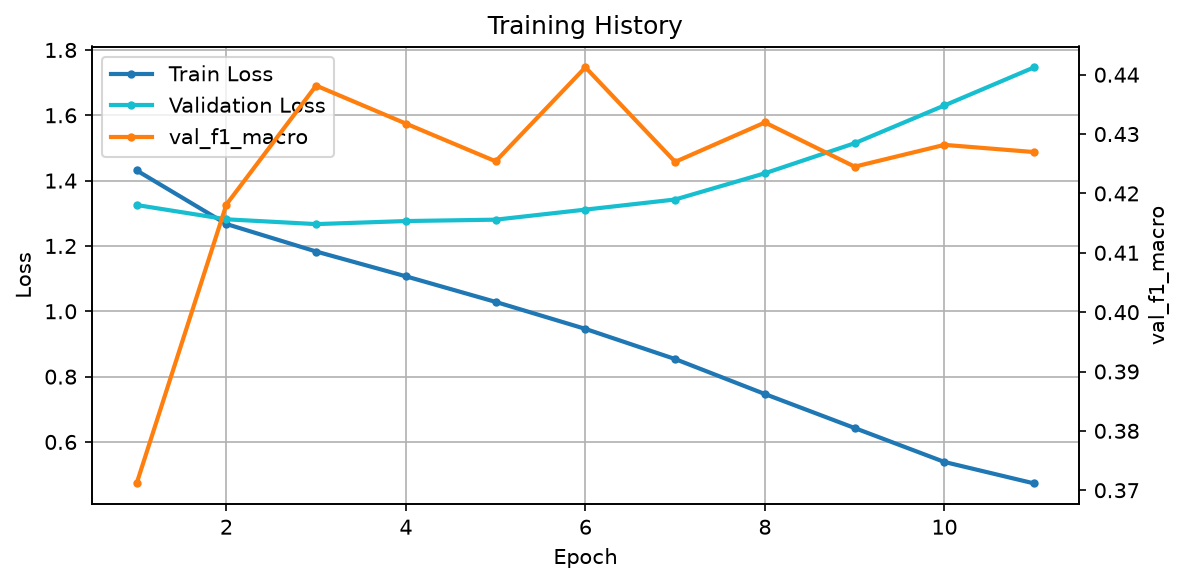

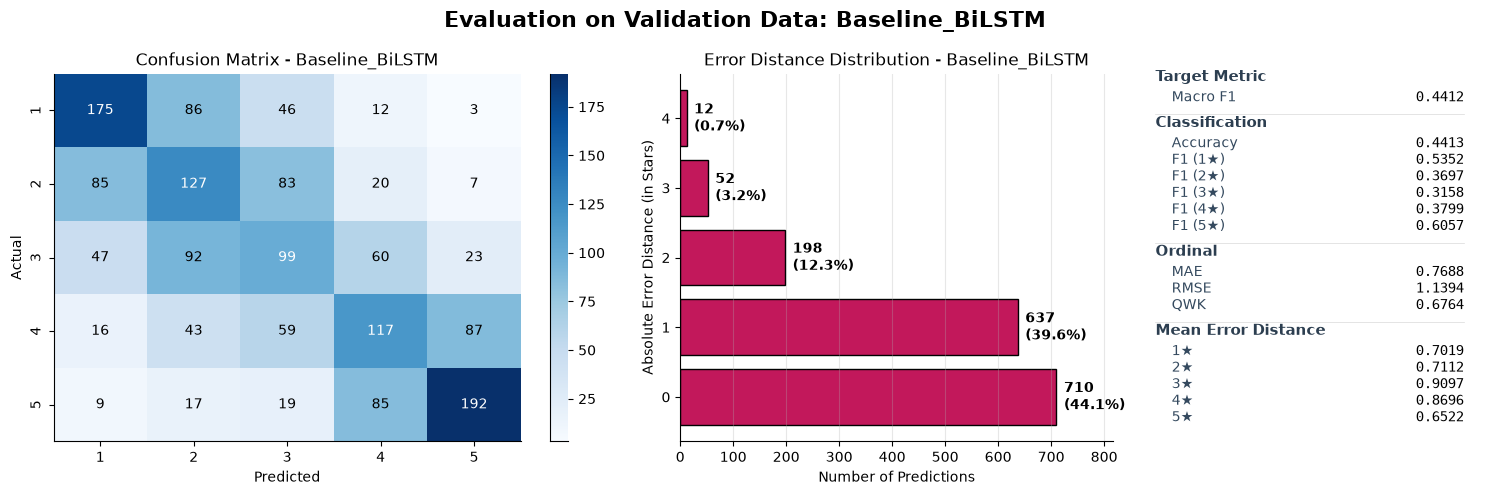

In [20]:
RUN_NAME = "Baseline_BiLSTM"

EMBEDDING_DIM = 64
HIDDEN_DIM = 128
NUM_CLASSES = 5

model = SentimentLSTM(
    vocab_size=len(vocab),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    padding_idx=vocab['<PAD>']
).to(device)

config = TrainingConfig(
    epochs=20,
    learning_rate=1e-3,
    optimizer=OptimizerType.ADAMW,
    monitor_metric=MonitorMetric.F1_MACRO,
    early_stopping_patience=5
)

print("Starting baseline BiLSTM training...")
trainer, run_id = train_and_log(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=config,
    run_name=RUN_NAME,
    tags={"architecture": "BiLSTM", "stage": "baseline"}
)

The baseline BiLSTM achieved a low-to-moderate Macro F1 score on the validation set, just above 0.4. Looking at the confusion matrix and the per-class F1 scores, the model shows higher accuracy at the polarity extremes — 1-star and 5-star reviews — while errors grow as we approach the 3-star class, the most ambiguous region of the scale. This pattern lends good support to the hypothesis that it is harder to semantically link a review's text to its star rating in more nuanced sentiment cases. 

It's also worth noting that most mistakes are "near misses", as more than 80% of validation predictions land within one star of the true rating, and the Quadratic Weighted Kappa (~0.7) points to substantial ordinal agreement despite the moderate exact-match accuracy. 

In other words, the BiLSTM does seem to capture the general sentiment gradient — it just struggles to draw sharp boundaries between adjacent classes, especially around the ambiguous middle. Whether this ceiling is intrinsic to the text-to-rating mapping or can still be pushed by a better-tuned model is what we investigate next.

### 3.7 Hyperparameter Search

Looking at the baseline's training history, `val_loss` bottoms out at very early epochs while `train_loss` keeps falling steadily — a fairly early train/validation split ("jaw" pattern) that suggests the model saturates its useful capacity quickly rather than needing more of it. This points the search toward regularization and optimization hyperparameters: **hidden_dim** (testing values at or below the baseline's 128), **dropout**, **learning_rate**, and **weight_decay**.

In [21]:
@dataclass
class SearchSpaceConfig:
    # Hyperparams to be tunned
    hidden_dim_options: Tuple[int, ...]
    dropout_range: Tuple[float, float]
    lr_range: Tuple[float, float]
    weight_decay_range: Tuple[float, float]

    # Train Config
    epochs: int
    optimizer: OptimizerType
    monitor_metric: MonitorMetric
    early_stopping_patience: int


default_search_config = SearchSpaceConfig(
    hidden_dim_options=(64, 96, 128),
    dropout_range=(0.1, 0.5),
    lr_range=(1e-4, 5e-3),
    weight_decay_range=(1e-4, 1e-1),
    epochs=20,
    optimizer=OptimizerType.ADAMW,
    monitor_metric=MonitorMetric.F1_MACRO,
    early_stopping_patience=4,
)

As the chosen framework for hyperparameter tuning here is Optune, we've decided to define and log trials as nested to a main Mlflow run. 

So the following `create_objective()` will serve not only to model our previous code into Optuna's pruning, but also as a means to structure the whole process into a single mlflow run, as below:
```
BiLSTM_Optuna_Search
  ├── trial_000
  ├── trial_001
  ├── trial_002
  └── ...      
```

In [22]:
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from utils.callbacks import OptunaPruningCallback

def create_objective(search_config: SearchSpaceConfig):
    def objective(trial: optuna.Trial) -> float:
        hidden_dim = trial.suggest_categorical("hidden_dim", search_config.hidden_dim_options)
        dropout = trial.suggest_float("dropout", *search_config.dropout_range)
        learning_rate = trial.suggest_float("learning_rate", *search_config.lr_range, log=True)
        weight_decay = trial.suggest_float("weight_decay", *search_config.weight_decay_range, log=True)

        model = SentimentLSTM(
            vocab_size=len(vocab),
            embedding_dim=EMBEDDING_DIM,
            hidden_dim=hidden_dim,
            num_classes=NUM_CLASSES,
            dropout=dropout,
            padding_idx=vocab['<PAD>'],
        ).to(device)

        config = TrainingConfig(
            epochs=search_config.epochs,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            optimizer=search_config.optimizer,
            monitor_metric=search_config.monitor_metric,
            early_stopping_patience=search_config.early_stopping_patience,
        )

        mlflow.start_run(run_name=f"trial_{trial.number:03d}", nested=True)
        try:
            mlflow.log_params({**asdict(config), "hidden_dim": hidden_dim, "dropout": dropout})  
            trainer = ClassifierTrainer(model, train_loader, val_loader, config, 
                    preprocessor, device, callbacks=[OptunaPruningCallback(trial)])
            trainer.fit()

            best_score = trainer.best.score if trainer.best is not None else float("-inf")
            mlflow.log_metric(trainer.monitor.name, best_score)
            mlflow.log_metric("best_epoch", trainer.best.epoch if trainer.best is not None else -1)
        except optuna.TrialPruned:
            if trainer.best is not None:
                mlflow.log_metric(trainer.monitor.name, trainer.best.score)
                mlflow.log_metric("best_epoch", trainer.best.epoch)
            mlflow.end_run(status="KILLED")
            raise
        else:
            mlflow.end_run()
            return best_score

    return objective

Finally, we can configure the Optuna study with three components:

- **TPE Sampler** (Tree-structured Parzen Estimator): a Bayesian optimization strategy that, unlike grid or random search, builds a probabilistic model of which regions of the hyperparameter space yield better scores. After an initial exploration phase, it progressively concentrates sampling around promising configurations. The `multivariate=True` flag lets TPE model interactions between hyperparameters (e.g., a high learning rate might pair better with a high dropout) rather than treating each one independently.
- **Median Pruner**: monitors the validation metric at each epoch and stops a trial early if its intermediate score falls below the median of scores reported by previous trials at the same epoch. `n_startup_trials=5` lets the first 5 trials run unpruned (to build a reliable baseline for comparison), and `n_warmup_steps=3` protects the first 3 epochs of every trial from pruning (since very early scores are noisy).
- **25 trials**: a modest budget, but well-suited to a 4-dimensional search where each trial converges (or gets pruned) within a few epochs. Bayesian sampling makes this far more efficient than a brute-force grid of equivalent size.

In [23]:
%%capture
RUN_NAME ="BiLSTM_Optuna_Search"
N_TRIALS = 25

sampler = TPESampler(seed=RANDOM_STATE, multivariate=True)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=3, interval_steps=1)

study = optuna.create_study(
    study_name=RUN_NAME,
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
)

[I 2026-08-01 11:02:03,821] A new study created in memory with name: BiLSTM_Optuna_Search


In [24]:
with mlflow.start_run(run_name=RUN_NAME, tags={"architecture": "BiLSTM", "stage": "hp_search"}) as parent_run:
    study.optimize(create_objective(default_search_config), n_trials=N_TRIALS, show_progress_bar=True)
    parent_run_id = parent_run.info.run_id

print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best val_f1_macro: {study.best_value:.4f}")
print(f"Best params: {study.best_trial.params}")

  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-08-01 11:02:24,364] Trial 0 finished with value: 0.4412205788925023 and parameters: {'hidden_dim': 96, 'dropout': 0.3394633936788146, 'learning_rate': 0.00018410729205738696, 'weight_decay': 0.00029375384576328325}. Best is trial 0 with value: 0.4412205788925023.
[I 2026-08-01 11:02:44,975] Trial 1 finished with value: 0.43431032886380044 and parameters: {'hidden_dim': 96, 'dropout': 0.3832290311184182, 'learning_rate': 0.00010838581269344756, 'weight_decay': 0.0812324508558869}. Best is trial 0 with value: 0.4412205788925023.
[I 2026-08-01 11:03:00,621] Trial 2 finished with value: 0.43411644771175234 and parameters: {'hidden_dim': 64, 'dropout': 0.17336180394137352, 'learning_rate': 0.0003287747413991121, 'weight_decay': 0.0037520558551242854}. Best is trial 0 with value: 0.4412205788925023.
[I 2026-08-01 11:03:14,187] Trial 3 finished with value: 0.43954718613096866 and parameters: {'hidden_dim': 128, 'dropout': 0.15579754426081674, 'learning_rate': 0.0003135775732257748, 'w

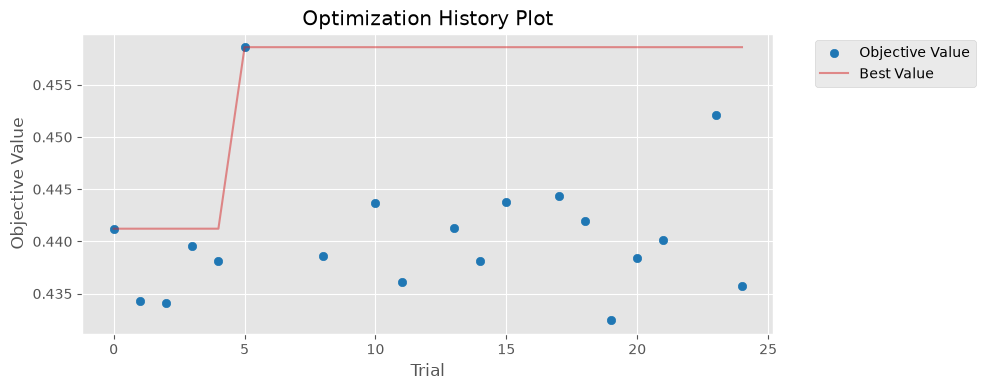

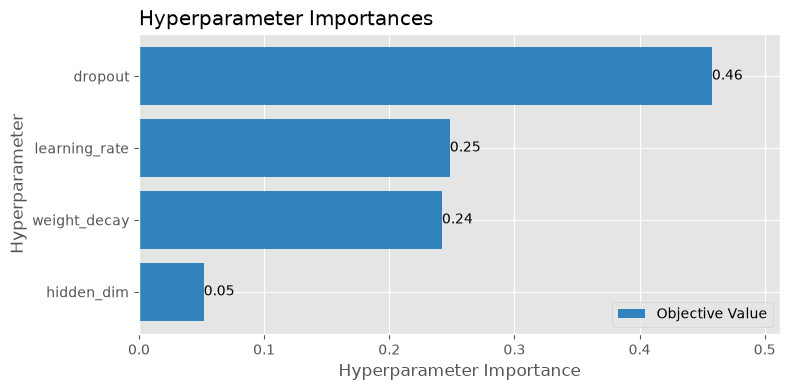

In [25]:
import optuna.visualization.matplotlib as optuna_plt
import matplotlib.pyplot as plt
import warnings
from optuna.exceptions import ExperimentalWarning
warnings.filterwarnings("ignore", category=ExperimentalWarning)

fig = optuna_plt.plot_optimization_history(study)
fig.figure.set_size_inches(10, 4)
plt.tight_layout()
plt.show()

fig = optuna_plt.plot_param_importances(study)
fig.figure.set_size_inches(8, 4)
plt.tight_layout()
plt.show()

The search explored 25 configurations, of which 10 were pruned early by the median pruner. All completed trials fell within a narrow Macro F1 band of 0.42–0.45, and the best trial (#5, F1 = 0.4586) improved over the baseline (0.4412) by less than one percentage point. The optimization history plot confirms this: the best value line flattens at trial 5 and remains unchanged for the remaining trials, a clear sign that the search has converged.

The hyperparameter importance analysis reveals that **weight decay** was the dominant factor (0.46), meaning that getting the L2 regularization strength right was what most separated good trials from mediocre ones.

The key takeaway is not the marginal F1 gain, but the confirmation that ~0.45 represents the practical ceiling for a BiLSTM trained from scratch on this data. The search space was well-covered, the best configurations cluster tightly, and further tuning would likely yield diminishing returns. This motivates the transition to pre-trained Transformer models.


## 4. Pre-trained Transformers

Section 3 established that a BiLSTM trained from scratch plateaus at a Macro F1 of ~0.45, regardless of hyperparameter tuning. Its core limitation is that it must learn word meanings from scratch using only our 7.5k training reviews and equally a 7.5k-word vocabulary, a signal for the subtle distinctions that separate a 2★ from a 3★.

Transformers approach the problem from the opposite direction. Pre-trained on billions of tokens via masked-language modeling, they arrive already "knowing" the language: contextual embeddings, syntax, and a great deal of world knowledge. Fine-tuning then adapts this general competence to our specific 5-class task with a small learning rate over just a few epochs. This is the Transfer Learning paradigm, and it is where we test whether richer linguistic representations can push past the BiLSTM's ceiling.

Key references:
- Vaswani, A., et al. (2017). *Attention Is All You Need*. NeurIPS 30. [[PDF](https://papers.neurips.cc/paper/7181-attention-is-all-you-need.pdf)] [[Youtube Video](https://www.youtube.com/watch?v=bCz4OMemCcA)]
- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL-HLT. [[PDF](https://aclanthology.org/N19-1423.pdf)]
- Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). *DistilBERT, a distilled version of BERT*. [[PDF](https://arxiv.org/pdf/1910.01108.pdf)]

### 4.1 Model Selection

Our data is in Portuguese, and the strongest base models are usually trained on English or multilingual corpora. We turn this limitation into the experiment: we select three small models, each chosen to answer a specific question about the interplay between language, model size, and task performance.

1. **BERTimbau** (`neuralmind/bert-base-portuguese-cased`, ~110M params) — *the specialist*. A BERT pre-trained from scratch on a large Brazilian Portuguese corpus. It answers: **how much is native-language pre-training worth?**

2. **mBERT** (`bert-base-multilingual-cased`, ~178M params) — *the generalist*. The same BERT architecture as BERTimbau, but pre-trained on 104 languages at once. Because the architecture is held constant, comparing it against BERTimbau isolates a single variable — the pre-training corpus. It answers: **can a multilingual model compensate for attention split across 104 languages?**

3. **DistilBERT** (`distilbert-base-uncased`, ~66M params) — *the negative control*. Smaller, faster, English-only, and uncased (it even strips accents, mapping "é"→"e"). It answers: **what does the language barrier actually cost?** If it performs surprisingly well, task structure matters more than language; if it collapses, native pre-training is essential.

All three expose the same Hugging Face interface (`AutoModelForSequenceClassification`), so a single `TransformerTrainer` will also fit all of them without modification.

In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

HF_DIR = Path("./hf")

MODELS = {
    "BERTimbau":     "neuralmind/bert-base-portuguese-cased",
    "mBERT":         "bert-base-multilingual-cased",
    "DistilBERT-en": "distilbert-base-uncased",
}

for name, model_id in MODELS.items():
    local_path = HF_DIR / name
    if not local_path.exists():
        AutoTokenizer.from_pretrained(model_id).save_pretrained(local_path)
        AutoModelForSequenceClassification.from_pretrained(
            model_id, num_labels=NUM_CLASSES
        ).save_pretrained(local_path)
    else:
        print(f"{name} already exists in {local_path}. Skipping...")

def load_model_and_tokenizer(name: str):
    local_path = str(HF_DIR / name)
    tokenizer = AutoTokenizer.from_pretrained(local_path)
    model = AutoModelForSequenceClassification.from_pretrained(
        local_path, num_labels=NUM_CLASSES
    )
    return tokenizer, model

BERTimbau already exists in hf\BERTimbau. Skipping...
mBERT already exists in hf\mBERT. Skipping...
DistilBERT-en already exists in hf\DistilBERT-en. Skipping...


### 4.2 The TransformerTrainer

Transformers change the data contract. Where the BiLSTM consumed a single tensor of token IDs, a Hugging Face model expects two tensors per example, i.e., `input_ids` and an `attention_mask` that flags real tokens versus padding, plus the `labels`. This difference propagates through the dataset, the training step, and the checkpoint format.

In [27]:
TR_MAX_LEN = 128      # covers our longest reviews (45 words)

class TransformerDataset(Dataset):
    """Tokenizes raw review text into (input_ids, attention_mask, labels) samples."""

    def __init__(self, X, y, tokenizer, max_len: int = TR_MAX_LEN) -> None:
        self.encodings = tokenizer(list(X), truncation=True, padding="max_length",
            max_length=max_len, return_tensors="pt")
        self.y = list(y)

    def __len__(self) -> int:
        return len(self.y)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": torch.tensor(self.y[idx], dtype=torch.long),
        }


Fine-tuning a pre-trained Transformer is a different training regime from the BiLSTM, and three techniques define it:

- **Full fine-tuning.** Although the training set contains only about 7.5k examples, this size is generally sufficient for full fine-tuning of compact Transformer models such as DistilBERT and BERT when conservative optimization settings (small learning rates, weight decay, and early stopping) are adopted. Freezing the encoder would reduce the risk of overfitting, but it would also prevent the model from adapting its internal representations to the subtle semantic distinctions required to discriminate adjacent review scores. Because our objective is to maximize Macro F1 across five closely related classes rather than obtain a computationally inexpensive baseline, full fine-tuning is our first choice.

- **Loss reuse instead of catastrophic forgetting mitigation via architecture.** `AutoModelForSequenceClassification` computes cross-entropy internally when `labels` are passed, returning it as `outputs.loss`, so we don't instantiate an external criterion as we did for the BiLSTM. The real safeguard against catastrophic forgetting here isn't the loss function, it's the learning rate and the scheduler below: the pre-trained weights must be perturbed just enough to specialize, not enough to forget.

- **Linear warmup followed by linear decay.** The scheduler ramps the learning rate up from ~0 over the first ~10% of training steps, then decays it back to ~0 over the remainder. The warmup phase exists because the classification head is randomly initialized while the encoder underneath it is already well-trained — starting at full learning rate would send large, noisy gradients from that random head backward through the encoder before it has any signal to work with, which is precisely how fine-tuning destroys pre-trained knowledge in the first few steps. Ramping up gives the head a chance to align with the encoder's representations first. The decay phase then follows the standard fine-tuning convention (as used to train BERT itself): shrinking the learning rate over time lets the optimizer settle into a sharper minimum rather than oscillating around it in the final epochs. Unlike the epoch-level scheduling one might use for a model trained from scratch, this scheduler is stepped once per *batch*, since the warmup window is measured in steps, not epochs.

Everything else — AdamW, gradient clipping, early stopping on the Macro F1 monitor — is carried over unchanged from `TrainingConfig`, so the only genuinely new machinery here is the scheduler and the shift from consuming raw token IDs to consuming `(input_ids, attention_mask, labels)` triples.


In [28]:
from transformers import get_linear_schedule_with_warmup

class TransformerTrainer(NNTrainer):
    """Fine-tunes a Hugging Face sequence-classification model."""

    def __init__(
        self, model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
        config: TrainingConfig, tokenizer, device: torch.device,
        callbacks: Sequence[TrainerCallback] | None = None, num_warmup_steps: int | None = None,
    ) -> None:
        super().__init__(model, train_loader, val_loader, config, device, callbacks)
        self.tokenizer = tokenizer
        self.optimizer = OPTIMIZERS[config.optimizer](self.model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
        self.monitor = MONITORS[config.monitor_metric]

        # Linear warmup + decay over the full (max) training horizon.
        total_steps = len(train_loader) * config.epochs
        warmup = num_warmup_steps if num_warmup_steps is not None else int(0.1 * total_steps)
        self.scheduler = get_linear_schedule_with_warmup(
            self.optimizer, num_warmup_steps=warmup, num_training_steps=total_steps
        )

    def _train_epoch(self) -> float:
        self.model.train()
        running_loss = 0.0
        for batch in self.train_loader:
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            labels = batch["labels"].to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss  # cross-entropy computed internally
            loss.backward()

            if self.config.grad_clip_norm is not None:
                nn.utils.clip_grad_norm_(self.model.parameters(), self.config.grad_clip_norm)

            self.optimizer.step()
            self.scheduler.step()  # per-batch step for linear warmup/decay
            running_loss += loss.item()

        return running_loss / len(self.train_loader)

    @torch.no_grad()
    def predict(self, loader: DataLoader) -> tuple[float, list, list]:
        """Runs inference over `loader`, returning (avg_loss, targets, predictions) in the 1–5 range."""
        self.model.eval()
        running_loss = 0.0
        targets, preds = [], []
        for batch in loader:
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            labels = batch["labels"].to(self.device)

            outputs = self.model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            running_loss += outputs.loss.item()
            # Same 0-4 -> 1-5 remap as the BiLSTM trainer, so MetricsEvaluator sees star labels.
            preds.extend((torch.argmax(outputs.logits, dim=1) + 1).cpu().tolist())
            targets.extend((labels + 1).cpu().tolist())

        return running_loss / len(loader), targets, preds

    def save(self, output_dir: str | Path) -> None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        self.model.save_pretrained(output_dir)
        self.tokenizer.save_pretrained(output_dir)

With `finetune_and_log()` we have a Transfer Learning mirror to the previously presented `train_and_log()` function:

In [29]:
def finetune_and_log(
    model: nn.Module, train_loader: DataLoader, val_loader: DataLoader,
    config: TrainingConfig, tokenizer, run_name: str, tags: dict | None = None,
    extra_params: dict | None = None, callbacks: Sequence[TrainerCallback] | None = None,
    num_warmup_steps: int | None = None,
) -> Tuple[TransformerTrainer, str]:
    """Runs a TransformerTrainer fine-tuning cycle inside one MLflow run."""

    with mlflow.start_run(run_name=run_name, tags=tags):
        run_id = mlflow.active_run().info.run_id
        print(f"Starting MLflow run: {run_id} | Name: {run_name}")
        params = asdict(config)
        if extra_params:
            params.update(extra_params)
        mlflow.log_params(params)

        trainer = TransformerTrainer(
            model, train_loader, val_loader, config, tokenizer, device,
            callbacks=callbacks if callbacks is not None else build_callbacks(),
            num_warmup_steps=num_warmup_steps,
        )
        trainer.fit()

        if trainer.best is not None:
            evaluator.evaluate(run_name, trainer.best.targets, trainer.best.preds, phase=EvaluationPhase.VALIDATION)

    return trainer, run_id

### 4.3 Fine-Tuning the Three Models

Fine-tuning inverts the training regime we used for the BiLSTM. Because the pre-trained weights are already good, we make small, careful updates: a low learning rate (`2e-5`, two orders of magnitude below the BiLSTM's `1e-3`), a short horizon (4 epochs), tight early stopping (patience 2), and gradient clipping at 1.0.

Each model brings its own tokenizer, so we rebuild the DataLoaders per model. The classification head is randomly initialized on top of the pre-trained encoder; the warnings Hugging Face prints about "newly initialized weights" are expected and are precisely what fine-tuning trains.

In [30]:
# 4.3 — model registry and per-model loader builder
TR_BATCH_SIZE = 32 # currently using a RTX 4060 with ~8GB VRAM

def build_transformer_loaders(tokenizer, batch_size: int = TR_BATCH_SIZE, max_len: int = TR_MAX_LEN):
    train_ds = TransformerDataset(X_train, y_train, tokenizer, max_len)
    val_ds   = TransformerDataset(X_val,   y_val,   tokenizer, max_len)
    test_ds  = TransformerDataset(X_test,  y_test,  tokenizer, max_len)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False),
    )


Fine-tuning BERTimbau  (neuralmind/bert-base-portuguese-cased)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Starting MLflow run: 9a647fa14727481eae55e233881e0b22 | Name: Finetuned_BERTimbau


Output()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

╭─────────────────────────────────────────────── Training Progress ───────────────────────────────────────────────╮
│ Epoch                7/10                                                                                       │
│ Train Loss         0.5938                                                                                       │
│ Val Loss           1.5245                                                                                       │
│ val_f1_macro       0.4801                                                                                       │
│ Best val_f1_macro  0.4831                                                                                       │
│ Best Epoch              5                                                                                       │
│ Patience              2/2                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

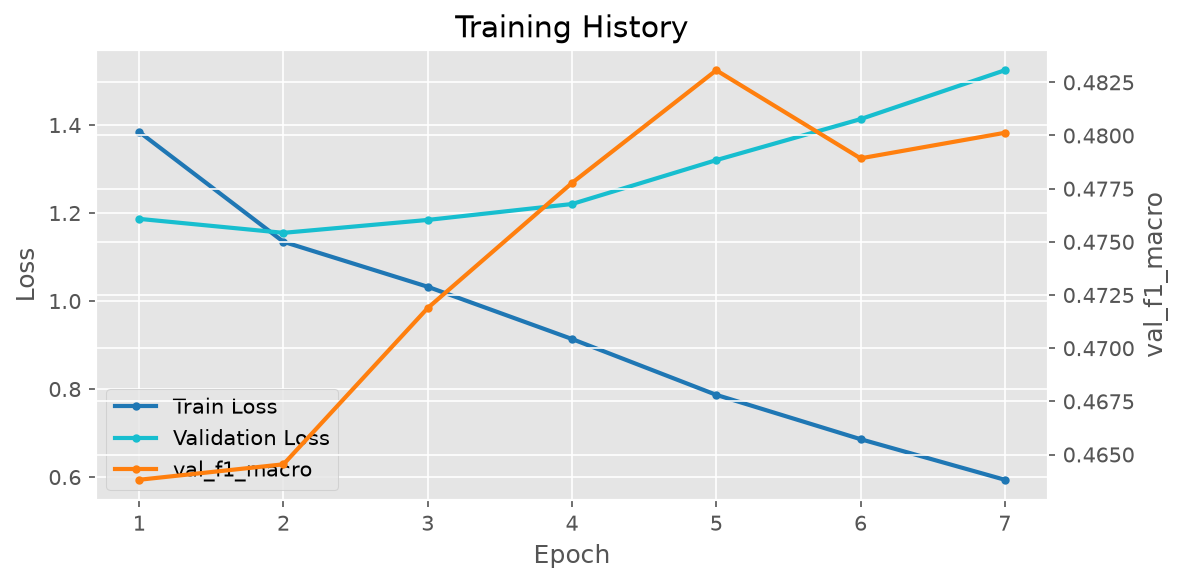

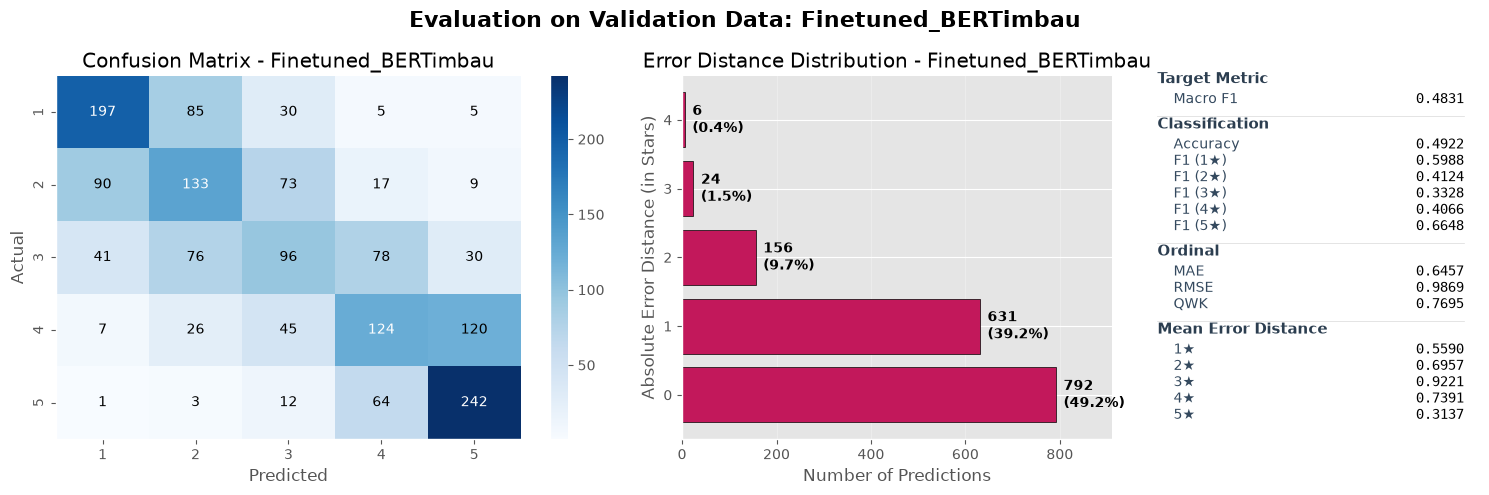


Fine-tuning mBERT  (bert-base-multilingual-cased)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Starting MLflow run: 41d8f871d6d0451f963edb977d1fad3f | Name: Finetuned_mBERT


Output()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

╭─────────────────────────────────────────────── Training Progress ───────────────────────────────────────────────╮
│ Epoch                6/10                                                                                       │
│ Train Loss         0.7799                                                                                       │
│ Val Loss           1.3953                                                                                       │
│ val_f1_macro       0.4625                                                                                       │
│ Best val_f1_macro  0.4736                                                                                       │
│ Best Epoch              4                                                                                       │
│ Patience              2/2                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

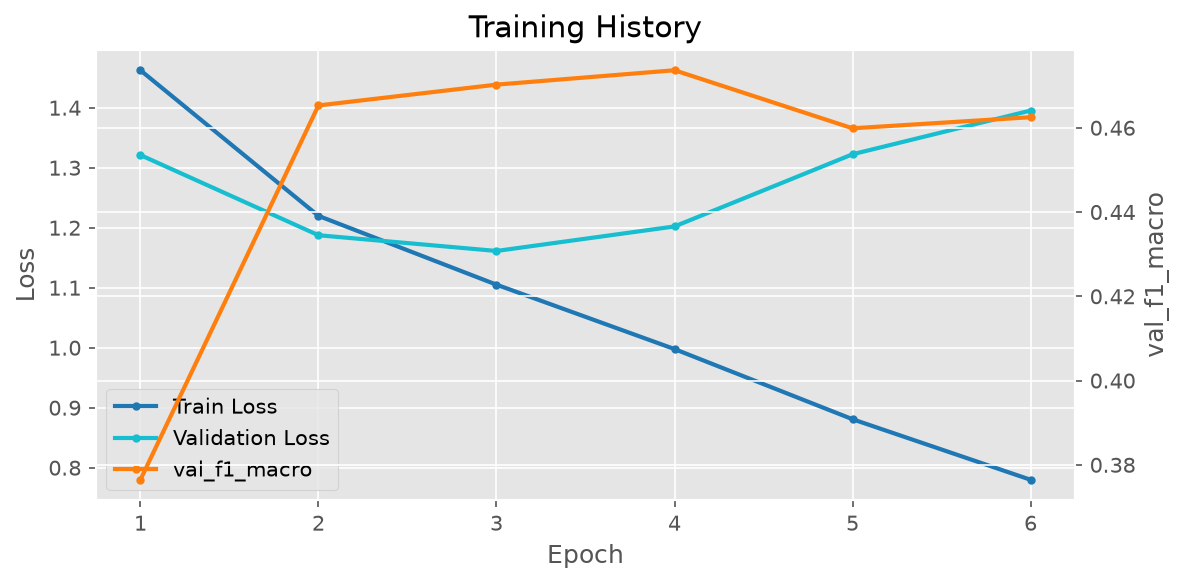

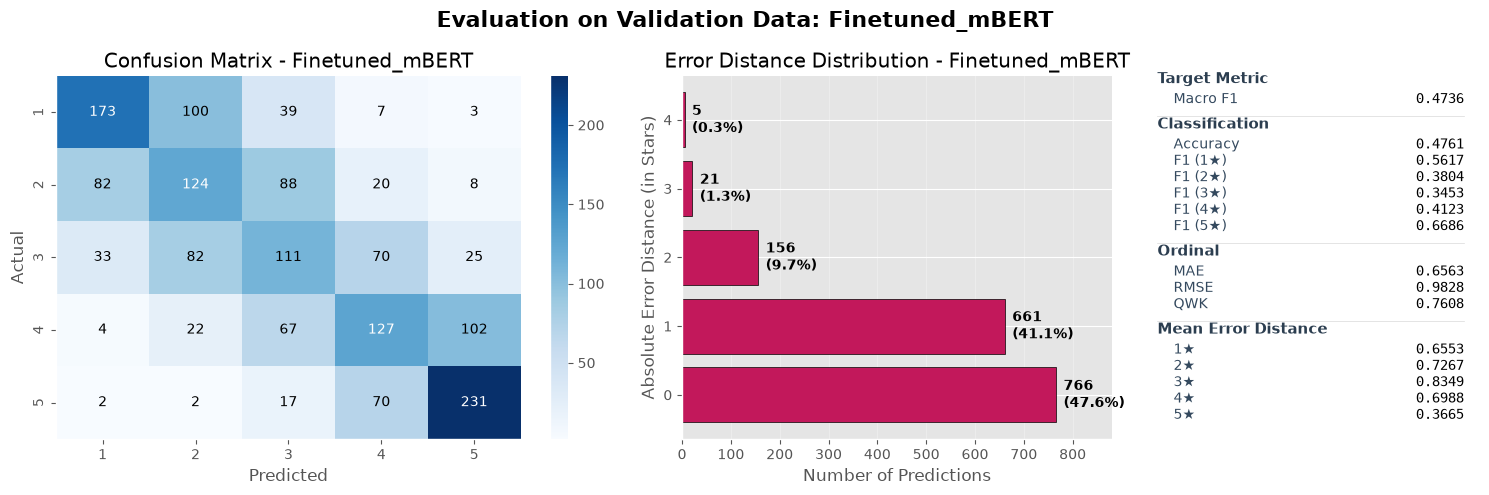


Fine-tuning DistilBERT-en  (distilbert-base-uncased)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Starting MLflow run: dd524814fc844adf9114b596d62f4eb9 | Name: Finetuned_DistilBERT-en


Output()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

╭─────────────────────────────────────────────── Training Progress ───────────────────────────────────────────────╮
│ Epoch               10/10                                                                                       │
│ Train Loss         0.8062                                                                                       │
│ Val Loss           1.3376                                                                                       │
│ val_f1_macro       0.4611                                                                                       │
│ Best val_f1_macro  0.4627                                                                                       │
│ Best Epoch              8                                                                                       │
│ Patience              2/2                                                                                       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

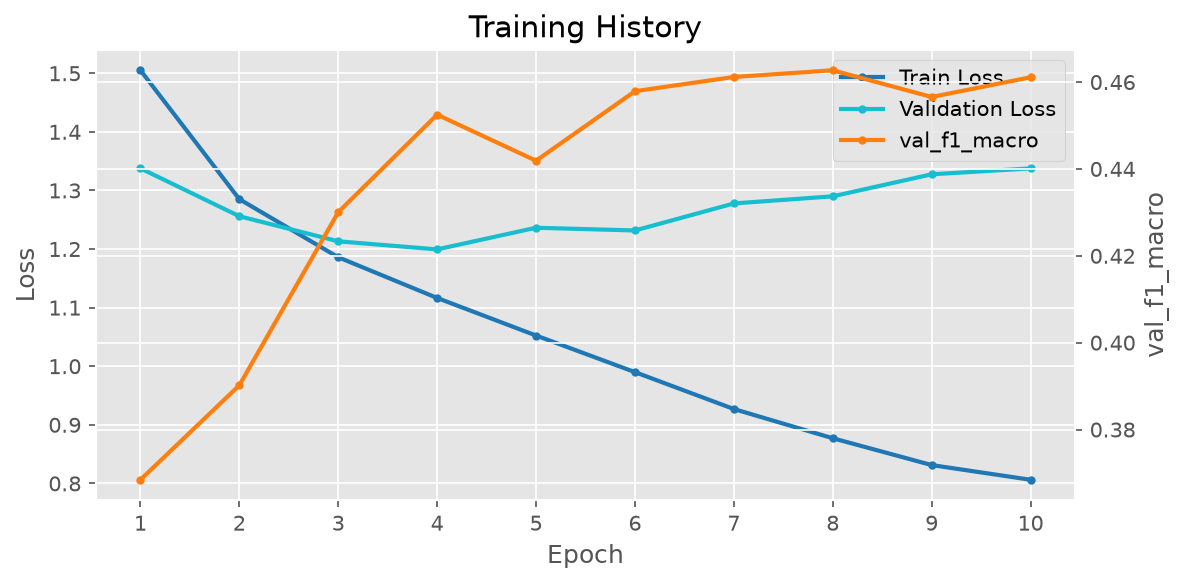

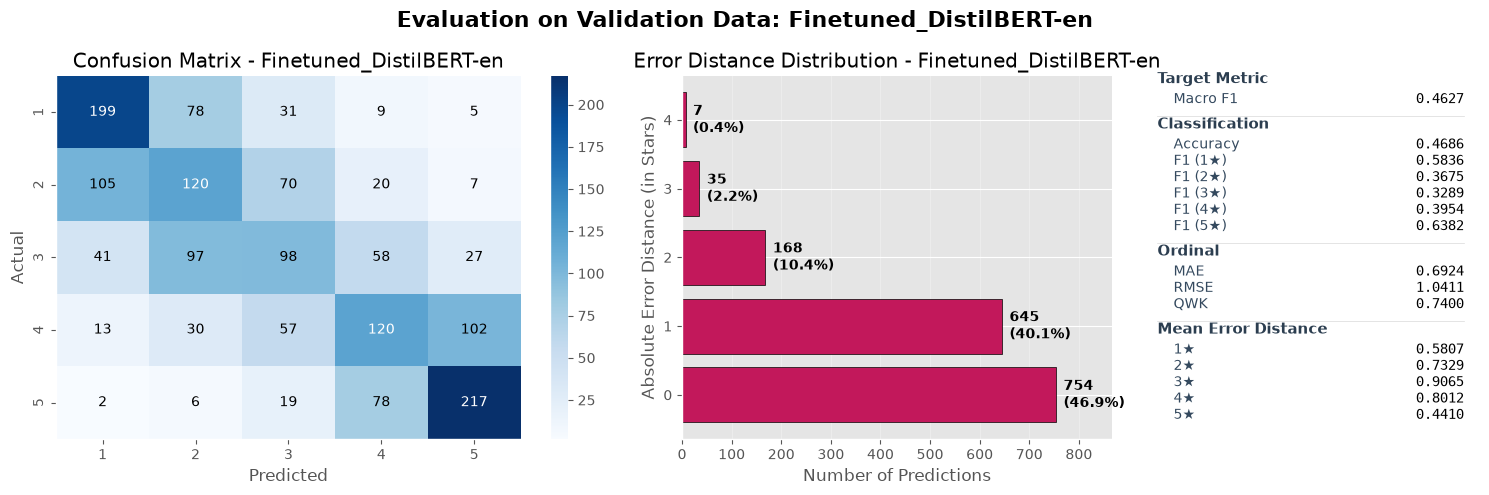

In [31]:
finetune_config = TrainingConfig(
    epochs=10, # we've tried it with 4, but as patient was'nt constantly defied, trying it with 10 seemed logical. 
    # The results were actually similar (probably related to the total_steps calculus, which has changed the learning rate trajectory).
    learning_rate=2e-5,
    weight_decay=1e-2,
    optimizer=OptimizerType.ADAMW,
    grad_clip_norm=1.0,
    monitor_metric=MonitorMetric.F1_MACRO,
    early_stopping_patience=2,
)

results: dict[str, dict] = {}

for name, model_id in MODELS.items():
    print(f"\n{'=' * 60}\nFine-tuning {name}  ({model_id})\n{'=' * 60}")

    tokenizer, model = load_model_and_tokenizer(name)
    train_loader_t, val_loader_t, _ = build_transformer_loaders(tokenizer)

    model.to(device)

    _, run_id = finetune_and_log(
        model=model,
        train_loader=train_loader_t,
        val_loader=val_loader_t,
        config=finetune_config,
        tokenizer=tokenizer,
        run_name=f"Finetuned_{name}",
        tags={"architecture": "Transformer", "stage": "finetune", "base_model": model_id},
        extra_params={"base_model": model_id, "max_len": TR_MAX_LEN},
    )

    results[name] = {"run_id": run_id, "model_id": model_id}

    del model
    torch.cuda.empty_cache()

The three fine-tuned Transformers land in a narrow Macro F1 band: BERTimbau at 0.4831, mBERT at 0.4736, and DistilBERT-en at 0.4627, all above the BiLSTM baseline (0.4476).

The three questions posed in Section 4.1 resolve as follows:

- **Native pre-training vs. multilingual (BERTimbau vs. mBERT):** BERTimbau finishes ahead, but by a slim 0.0095 Macro F1 — small enough that we read it as a mild edge rather than a decisive win. Where does the edge come from? Reading the per-class F1 side by side, BERTimbau's advantage is concentrated at and near the poles: it posts the best 1★ (0.60) and the best 2★ (0.41) of the three, and ties mBERT at the top for 5★ (0.66). In the exact middle it is actually the *weakest* of the trio (3★ 0.33, just below mBERT's 0.35), and it trails mBERT on 4★ as well (0.41 vs 0.41). So the native model's benefit here is sharper handling of the clearly-negative and clearly-positive ends, not a better grip on the ambiguous center. 

(This is worth flagging against an earlier single-run observation, in which BERTimbau appeared to lift the *middle* classes together; re-running did not reproduce that pattern, a reminder that per-class differences this small are within run-to-run variance from random head initialization. Section 5 re-checks the surviving differences on the untouched test set.)

- **The language barrier (DistilBERT-en):** the English, accent-stripping model is the weakest of the three, but only by ~0.011 relative to mBERT. Its survival is the more interesting result: a model that never saw Portuguese pre-training and maps "não" → "nao" still reaches 0.4627, comfortably above the from-scratch BiLSTM — and it even edges mBERT on 1★ (0.58 vs 0.56). Its per-class profile is otherwise the familiar one — strong poles, weak middle (3★ 0.33). Much of the star-rating signal is evidently carried by cues robust enough to survive a mismatched tokenizer; the task leans more on general sentiment structure than on fine Portuguese morphology.

- **Model size:** DistilBERT-en (66M) trailing the larger BERT-family models (110–178M) is consistent with size helping, but the effect is small and confounded with the language mismatch, so we don't over-read it.

Most telling for this project's central question is what did *not* change. Across all three models the error profile is nearly identical to the BiLSTM's: roughly 47–49% exact matches plus ~39–41% off-by-one predictions, so about 87% of predictions still land within a single star, and QWK holds around 0.74–0.77. The confusion matrices keep the same shape — confident poles, blurred center — and the 3★ class remains the hardest to identify in *every* model, sitting at 0.33–0.35 regardless of architecture, language, or size, essentially unchanged from the BiLSTM baseline's ~0.33. No model, however it was pre-trained, pulled the middle of the scale up.

Moving from a word-level BiLSTM to billion-token pre-trained encoders bought a small, consistent gain in overall accuracy — the poles got sharper — while leaving the ambiguous middle of the rating scale essentially untouched. This is strong evidence that the difficulty around 3★ is largely a property of the data rather than a representational limitation.

### 4.4 The Other Extreme: Feature Extraction

With feature extraction, we freeze the pre-trained encoder entirely, pass each review through it once to obtain a single vector (a pooled representation of the whole sentence), and train a simple Logistic Regression on top of those vectors. The encoder never learns anything about reviews; it contributes only the general linguistic knowledge it already had. Why add this step before the final comparison?

1. **It localizes where the signal lives.** If a frozen encoder's raw embeddings already separate 1★ from 5★ under a linear classifier, then the polarity distinction is *linearly encoded in general-purpose language representations*, i. e., the model doesn't need to learn it from our data. Conversely, if the ambiguous middle (3★) stays tangled even in these rich embeddings, that is strong evidence the difficulty is intrinsic to the data.

2. **It is a genuine competitor, not just a diagnostic.** On small datasets, feature extraction can beat fine-tuning: a frozen encoder plus a low-variance linear model cannot drift from its pre-trained knowledge. Whether fine-tuning's added flexibility pays off or backfires on our data is exactly the kind of question Section 5 will settle.

We run feature extraction on the same three models, so every base model is tested under both regimes.

In [32]:
import gc
import joblib
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from transformers import AutoModel


class TransformerFeatureExtractor:
    """Freezes a pre-trained encoder, extracts embeddings, and fits a
    Logistic Regression classifier on top."""

    def __init__(self, model_path: str, tokenizer, device: torch.device, model_id: str | None = None,
                 max_len: int = TR_MAX_LEN, batch_size: int = TR_BATCH_SIZE) -> None:
        self.model_path = model_path            
        self.model_id = model_id or model_path  
        self.tokenizer = tokenizer
        self.device = device
        self.max_len = max_len
        self.batch_size = batch_size
        self.classifier = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000, class_weight="balanced"),
        )

    @torch.no_grad()
    def _embed(self, X) -> np.ndarray:
        """Loads the frozen encoder, extracts the [CLS] embedding per example,
        then releases the encoder before returning."""
        encoder = AutoModel.from_pretrained(self.model_path).to(self.device).eval()
        loader = DataLoader(
            TransformerDataset(X, np.zeros(len(X)), self.tokenizer, self.max_len),
            batch_size=self.batch_size, shuffle=False,
        )
        embeddings = []
        try:
            for batch in loader:
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                outputs = encoder(input_ids=input_ids, attention_mask=attention_mask)
                # last_hidden_state[:, 0] is the [CLS] token: a pooled sentence representation.
                embeddings.append(outputs.last_hidden_state[:, 0, :].cpu().numpy())
        finally:
            del encoder
            gc.collect()
            torch.cuda.empty_cache()
        return np.vstack(embeddings)

    def fit(self, X_train, y_train) -> "TransformerFeatureExtractor":
        self.classifier.fit(self._embed(X_train), y_train)
        return self

    def predict(self, X) -> np.ndarray:
        return self.classifier.predict(self._embed(X)) + 1

    def save(self, output_dir: str | Path) -> None:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        # The encoder is not re-saved: it already lives at self.model_path.
        # We persist only the trained head plus a pointer/config to rebuild the pair.
        joblib.dump(self.classifier, output_dir / "classifier.joblib")
        with open(output_dir / "config.json", "w", encoding="utf-8") as f:
            json.dump({"model_path": str(self.model_path), "model_id": self.model_id,
                       "max_len": self.max_len, "pooling": "cls", "strategy": "feature_extraction"
                       }, f, indent=4)

In [33]:
def extract_and_log(
    model_path: str, tokenizer, run_name: str, model_id: str | None = None,
    tags: dict | None = None, extra_params: dict | None = None,
) -> str:
    """Fits a pair of encoder + LogisticRegression classifier inside one MLflow run."""

    with mlflow.start_run(run_name=run_name, tags=tags):
        run_id = mlflow.active_run().info.run_id
        print(f"Starting MLflow run: {run_id} | Name: {run_name}")
        params = {"base_model": model_id or model_path, "model_path": model_path,
                  "max_len": TR_MAX_LEN, "strategy": "feature_extraction",
                  "classifier": "logreg", "pooling": "cls"}
        if extra_params:
            params.update(extra_params)
        mlflow.log_params(params)

        extractor = TransformerFeatureExtractor(model_path, tokenizer, device, model_id=model_id)
        extractor.fit(X_train, y_train)

        val_preds = extractor.predict(X_val).tolist()
        val_targets = (np.asarray(y_val) + 1).tolist()  # 0-idx -> 1-5 star range
        evaluator.evaluate(run_name, val_targets, val_preds, phase=EvaluationPhase.VALIDATION)

        extractor.save("fe_model")
        try:
            mlflow.log_artifacts(local_dir="fe_model", artifact_path="feature_extractor")
        finally:
            shutil.rmtree("fe_model", ignore_errors=True)

    return run_id


Feature extraction: BERTimbau  (hf\BERTimbau)
Starting MLflow run: 1f6b1dbb66c245ccb8c18c1464287488 | Name: FE_BERTimbau


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: hf\BERTimbau
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: hf\BERTimbau
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


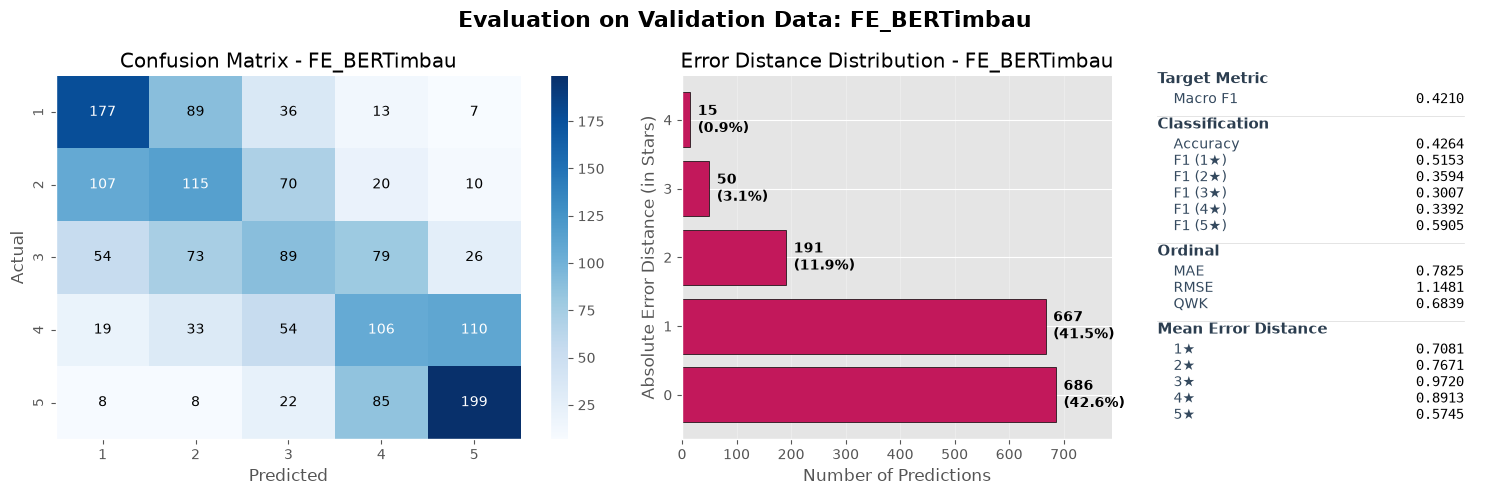


Feature extraction: mBERT  (hf\mBERT)
Starting MLflow run: 0ef173bf94dc482a9cd85984d1dadc5b | Name: FE_mBERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: hf\mBERT
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: hf\mBERT
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


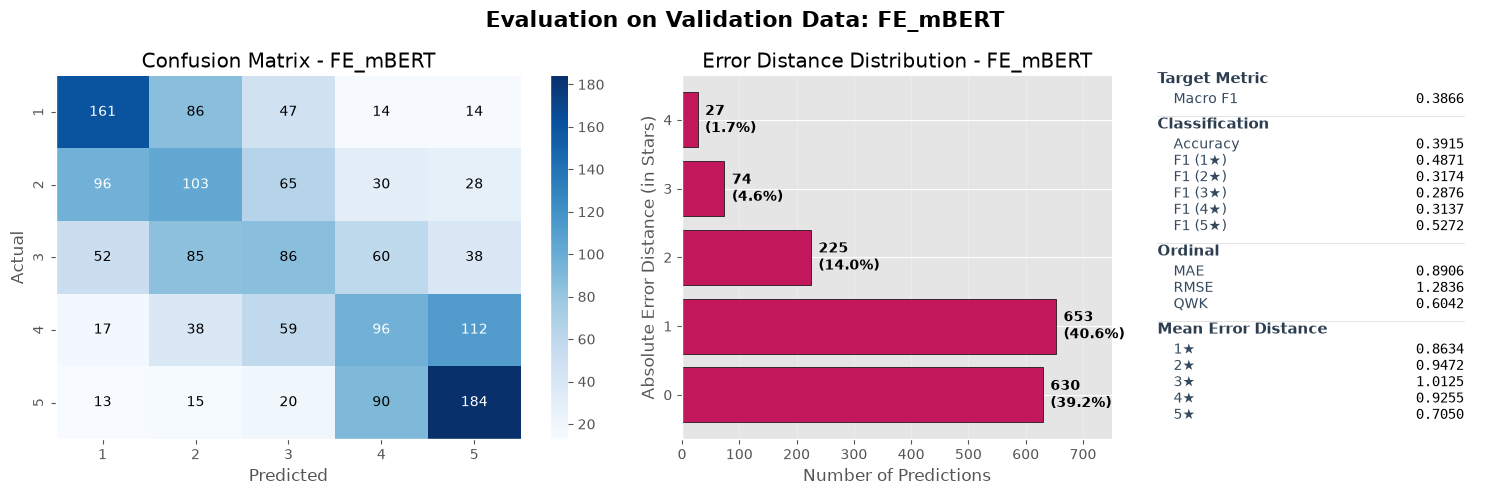


Feature extraction: DistilBERT-en  (hf\DistilBERT-en)
Starting MLflow run: ec14c6cd9fdd407788404126aafb2168 | Name: FE_DistilBERT-en


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: hf\DistilBERT-en
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.weight | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: hf\DistilBERT-en
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.weight | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


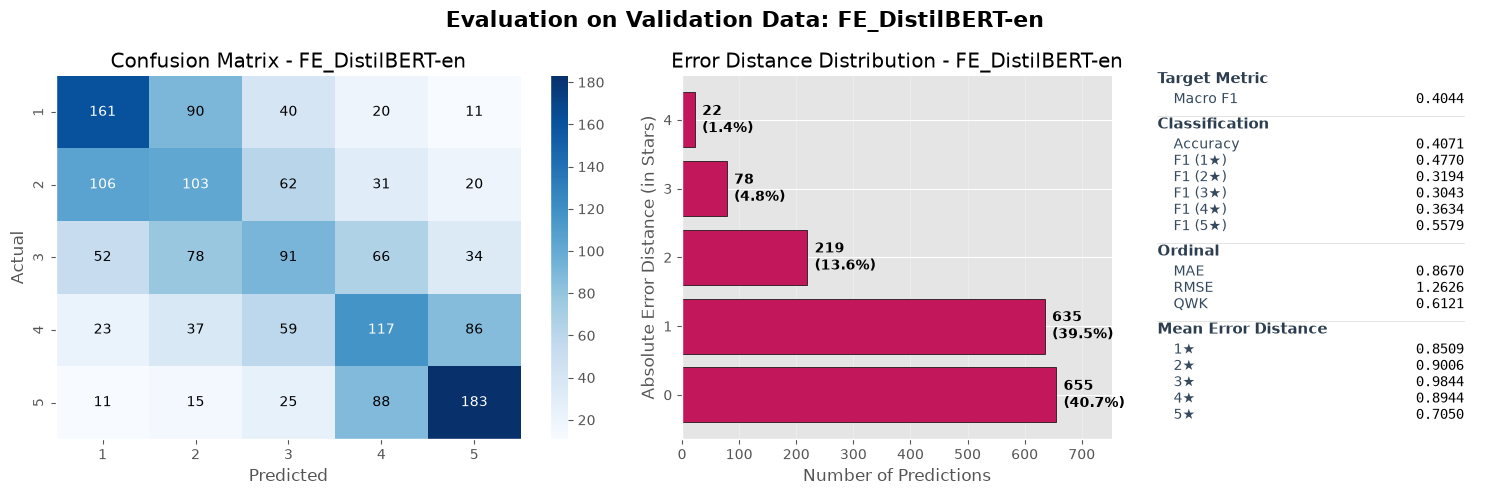

In [34]:
fe_results: dict[str, dict] = {}

for name, model_id in MODELS.items():
    local_path = str(HF_DIR / name)
    print(f"\n{'=' * 60}\nFeature extraction: {name}  ({local_path})\n{'=' * 60}")

    tokenizer = AutoTokenizer.from_pretrained(local_path)
    run_id = extract_and_log(
        model_path=local_path,
        model_id=model_id,                     
        tokenizer=tokenizer,
        run_name=f"FE_{name}",
        tags={"architecture": "Transformer", "stage": "feature_extraction", "base_model": model_id},
    )
    fe_results[name] = {"run_id": run_id, "model_path": local_path, "model_id": model_id}

The results settle the two questions this section set out to answer, and they do so cleanly.

**Fine-tuning wins across the board.** Every frozen extractor underperforms its fine-tuned counterpart: BERTimbau drops from 0.4831 to 0.4210, mBERT from 0.4736 to 0.3866, and DistilBERT-en from 0.4627 to 0.4044 — a consistent 0.05–0.09 Macro F1 penalty for freezing the encoder. On this data, the flexibility of updating the encoder pays off; the small-dataset scenario where feature extraction beats fine-tuning did not materialize. BERTimbau leads the frozen group just as it led the fine-tuned one, and the gap over mBERT actually *widens* under freezing (0.42 vs 0.39).

**The signal localization is the real payoff.** Look at where the frozen embeddings succeed and fail. Even with an untouched encoder and nothing but a linear classifier on top, the poles hold up remarkably well — 1★ sits at 0.48–0.52 and 5★ at 0.53–0.59 across all three models, not far below their fine-tuned values. This is direct evidence for the first motivation of this section: **the polarity distinction is already linearly encoded in general-purpose language representations.** A model that never saw a single Olist review can separate "clearly negative" from "clearly positive" out of the box; that competence comes for free from pre-training, not from our data.

The middle tells the opposite story. The 3★ F1 falls to ~0.29–0.30 for all three frozen models — the worst 3★ scores anywhere in the notebook. Taken together, the two regimes triangulate the project's central hypothesis from both sides. The extremes are cheap: they survive in frozen, general-purpose embeddings without any task-specific training. The middle is expensive and fragile: fine-tuning barely lifts it above the baseline, and freezing pushes it below. The difficulty around 3★ is therefore not something a better application of pre-trained knowledge dissolves.

## 5. Final Comparison

To compare the approaches fairly, we now evaluate each model once on the held-out test set, which no model or decision has touched. **We will reload each trained model from its MLflow artifact and run it over the test set.**  All approaches will be ranked by Macro F1 and a close eye will be put on the 3★ class, the ambiguous middle whose behaviour has been the project's central question.


Test-set evaluation: Baseline_BiLSTM  (stage: baseline)


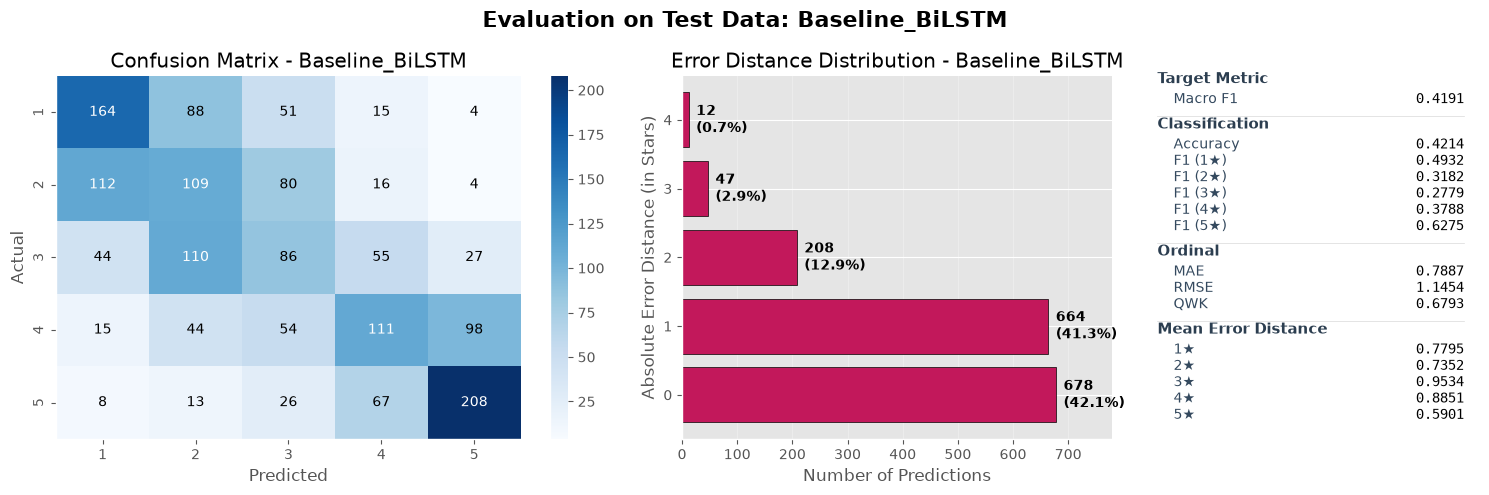


Test-set evaluation: Finetuned_BERTimbau  (stage: finetune)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

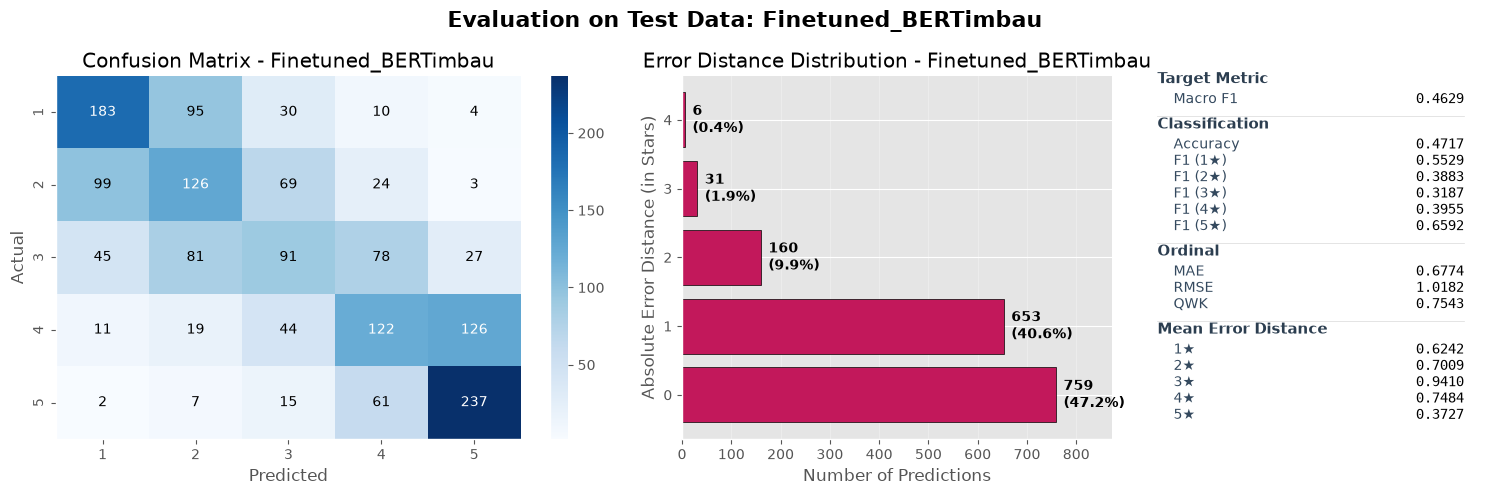


Test-set evaluation: Finetuned_mBERT  (stage: finetune)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

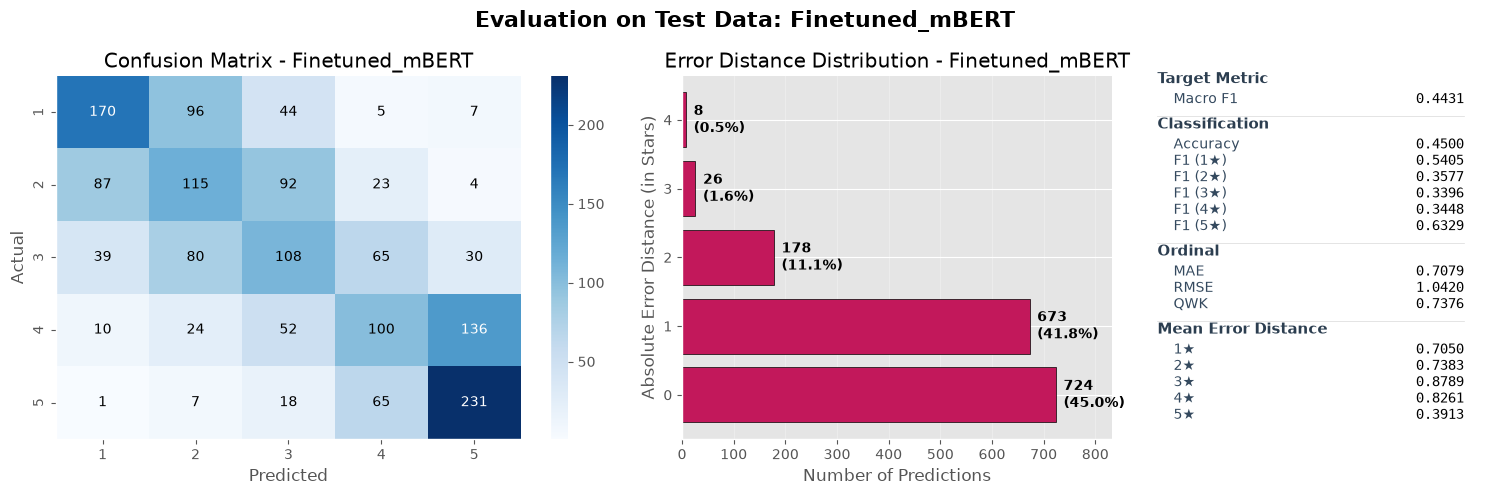


Test-set evaluation: Finetuned_DistilBERT-en  (stage: finetune)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

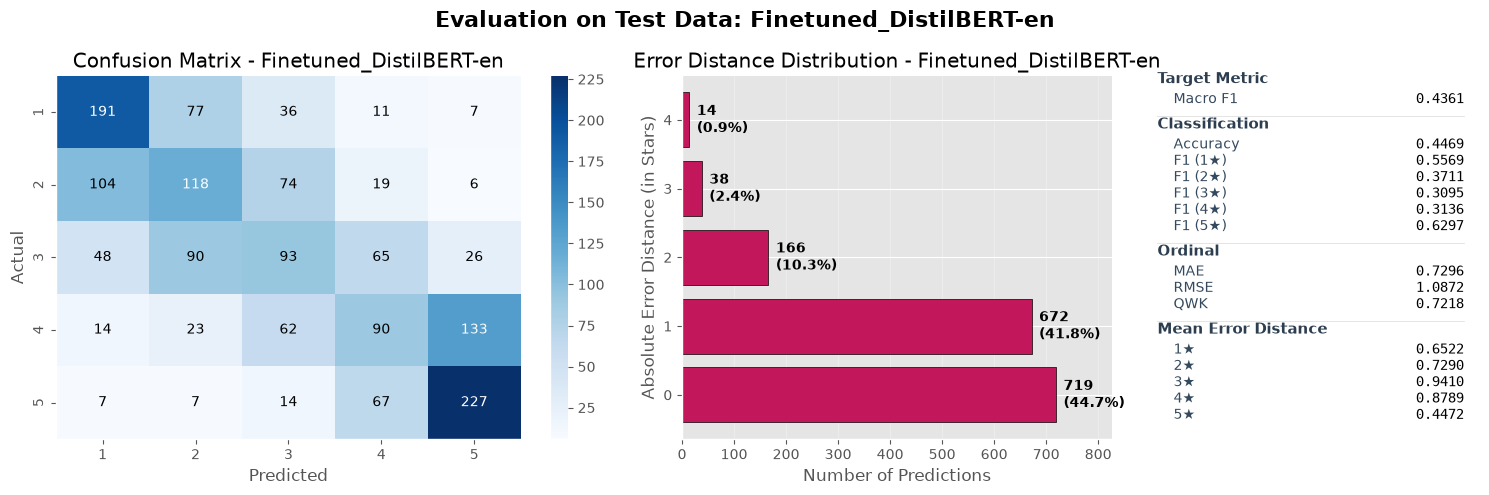


Test-set evaluation: FE_BERTimbau  (stage: feature_extraction)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: hf\BERTimbau
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


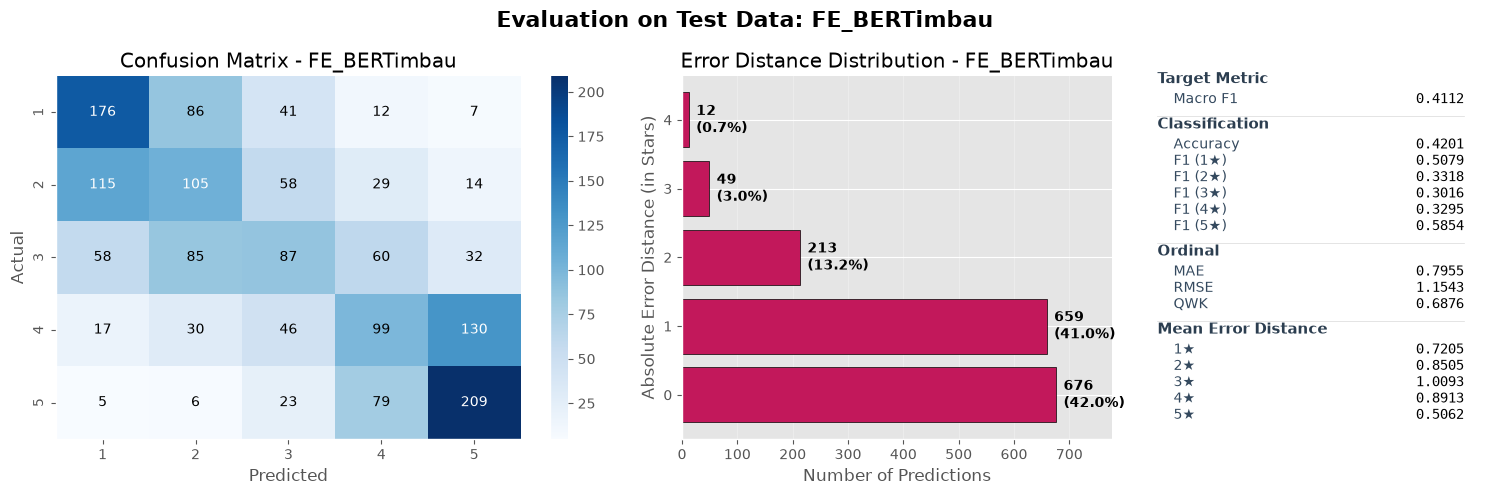


Test-set evaluation: FE_mBERT  (stage: feature_extraction)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: hf\mBERT
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


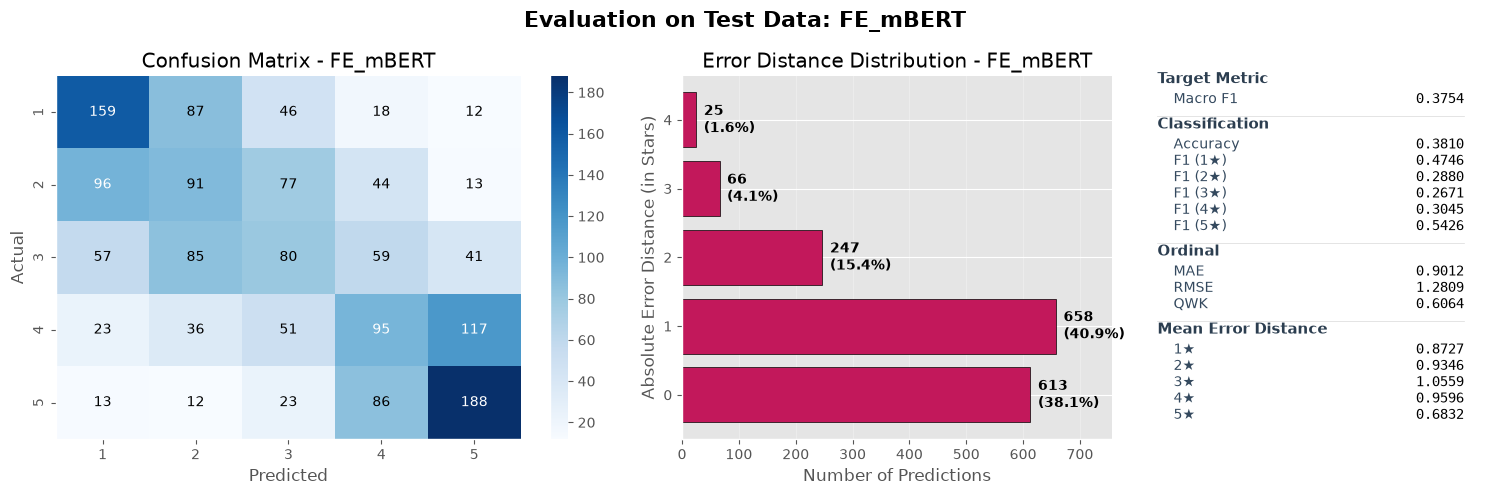


Test-set evaluation: FE_DistilBERT-en  (stage: feature_extraction)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: hf\DistilBERT-en
Key                   | Status     |  | 
----------------------+------------+--+-
pre_classifier.weight | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


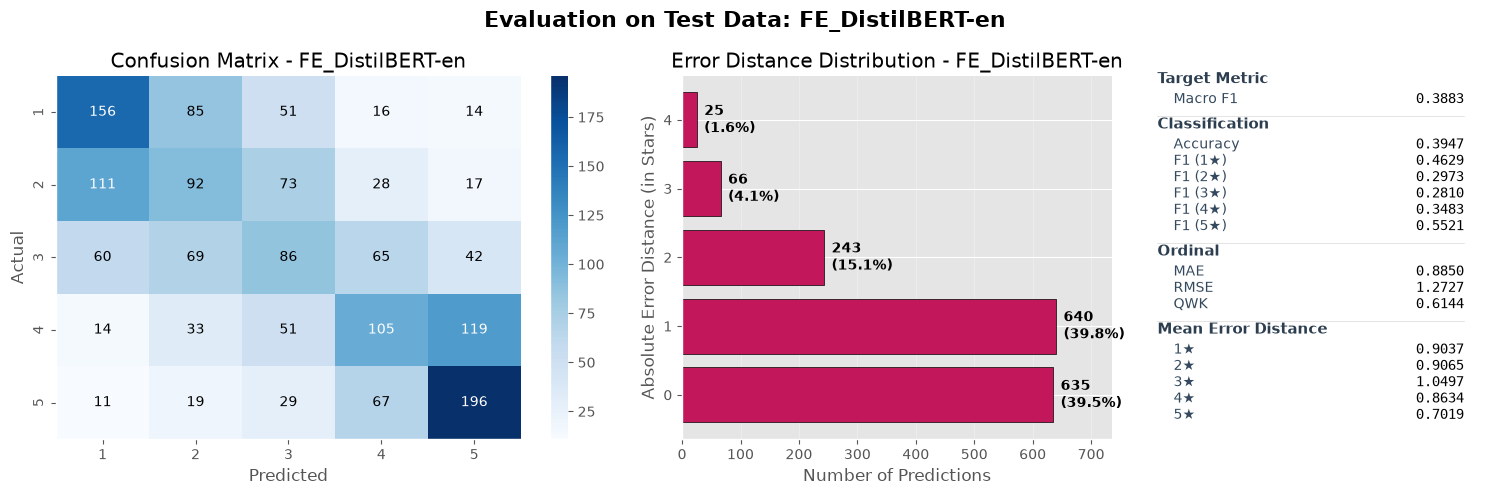

In [ ]:
from utils.evaluation import MetricsEvaluator, EvaluationPhase

evaluator = MetricsEvaluator()

COMPARISON_RUNS = {
    "5e2810b40c6f41bb8482ebdd142395a1": "Baseline_BiLSTM",
    "9a647fa14727481eae55e233881e0b22": "Finetuned_BERTimbau",
    "41d8f871d6d0451f963edb977d1fad3f": "Finetuned_mBERT",
    "dd524814fc844adf9114b596d62f4eb9": "Finetuned_DistilBERT-en",
    "1f6b1dbb66c245ccb8c18c1464287488": "FE_BERTimbau",
    "0ef173bf94dc482a9cd85984d1dadc5b": "FE_mBERT",
    "ec14c6cd9fdd407788404126aafb2168": "FE_DistilBERT-en",
}


def _predict_finetune(run_id: str) -> tuple[list, list]:
    """Reload a fine-tuned Transformer (save_pretrained artifact) and predict on test."""
    local_dir = mlflow.artifacts.download_artifacts(run_id=run_id, artifact_path="model")
    tokenizer = AutoTokenizer.from_pretrained(local_dir)
    model = AutoModelForSequenceClassification.from_pretrained(local_dir).to(device)
    _, _, test_loader_t = build_transformer_loaders(tokenizer)
    trainer = TransformerTrainer(model, test_loader_t, test_loader_t,
                                 finetune_config, tokenizer, device, callbacks=[])
    _, y_true, y_pred = trainer.predict(test_loader_t)
    del model, trainer
    torch.cuda.empty_cache()
    return y_true, y_pred


def _predict_feature_extraction(run_id: str) -> tuple[list, list]:
    """Reload a frozen-encoder + LogReg head (joblib + config artifact) and predict on test."""
    fe_dir = mlflow.artifacts.download_artifacts(run_id=run_id, artifact_path="feature_extractor")
    fe_cfg = json.load(open(Path(fe_dir) / "config.json", encoding="utf-8"))
    tokenizer = AutoTokenizer.from_pretrained(fe_cfg["model_path"])
    extractor = TransformerFeatureExtractor(
        fe_cfg["model_path"], tokenizer, device,
        model_id=fe_cfg.get("model_id"), max_len=fe_cfg["max_len"],
    )
    extractor.classifier = joblib.load(Path(fe_dir) / "classifier.joblib")
    y_pred = extractor.predict(X_test).tolist()
    y_true = (np.asarray(y_test) + 1).tolist()
    del extractor
    gc.collect()
    torch.cuda.empty_cache()
    return y_true, y_pred


def _predict_bilstm(run_id: str) -> tuple[list, list]:
    """Reload the BiLSTM (state_dict + model.json artifact) and predict on test."""
    art = mlflow.artifacts.download_artifacts(run_id=run_id, artifact_path="model")
    cfg = json.load(open(Path(art) / "model.json"))
    model = SentimentLSTM(**cfg).to(device)
    model.load_state_dict(torch.load(Path(art) / "state_dict.pt", map_location=device))
    trainer = ClassifierTrainer(model, test_loader, test_loader,
                                TrainingConfig(), preprocessor, device, callbacks=[])
    _, y_true, y_pred = trainer.predict(test_loader)
    del model, trainer
    torch.cuda.empty_cache()
    return y_true, y_pred

PREDICTORS = {
    "finetune":           _predict_finetune,
    "feature_extraction": _predict_feature_extraction,
    "baseline":           _predict_bilstm,
}

for run_id, run_name in COMPARISON_RUNS.items():
    stage = mlflow.get_run(run_id).data.tags["stage"]
    print(f"\n{'=' * 60}\nTest-set evaluation: {run_name}  (stage: {stage})\n{'=' * 60}")
    y_true, y_pred = PREDICTORS[stage](run_id)
    with mlflow.start_run(run_id=run_id):
        evaluator.evaluate(run_name, y_true, y_pred, phase=EvaluationPhase.TEST)

In [ ]:
runs_df = mlflow.search_runs(order_by=["metrics.test_macro_f1 DESC"])
mask = runs_df["run_id"].isin(COMPARISON_RUNS)

cols = {
    "run_id": "run_id",
    "tags.mlflow.runName": "model",
    "tags.stage": "stage",
    "metrics.test_macro_f1": "macro_f1",
    "metrics.test_accuracy": "accuracy",
    "metrics.test_qwk": "qwk",
    "metrics.test_mae": "mae",
    "metrics.test_f1_class_1_stars": "f1_1★",
    "metrics.test_f1_class_3_stars": "f1_3★",
    "metrics.test_f1_class_5_stars": "f1_5★",
}

leaderboard = (
    runs_df.loc[mask, list(cols)]
    .rename(columns=cols)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

leaderboard.style.format({
    "macro_f1": "{:.4f}", "accuracy": "{:.4f}", "qwk": "{:.4f}", "mae": "{:.4f}",
    "f1_1★": "{:.4f}", "f1_3★": "{:.4f}", "f1_5★": "{:.4f}",
}).background_gradient(subset=["macro_f1", "qwk"], cmap="YlGn")

,run_id,model,stage,macro_f1,accuracy,qwk,mae,f1_1★,f1_3★,f1_5★
0,9a647fa14727481eae55e233881e0b22,Finetuned_BERTimbau,finetune,0.4629,0.4717,0.7543,0.6774,0.5529,0.3187,0.6592
1,41d8f871d6d0451f963edb977d1fad3f,Finetuned_mBERT,finetune,0.4431,0.4500,0.7376,0.7079,0.5405,0.3396,0.6329
2,dd524814fc844adf9114b596d62f4eb9,Finetuned_DistilBERT-en,finetune,0.4361,0.4469,0.7218,0.7296,0.5569,0.3095,0.6297
3,5e2810b40c6f41bb8482ebdd142395a1,Baseline_BiLSTM,baseline,0.4191,0.4214,0.6793,0.7887,0.4932,0.2779,0.6275
4,1f6b1dbb66c245ccb8c18c1464287488,FE_BERTimbau,feature_extraction,0.4112,0.4201,0.6876,0.7955,0.5079,0.3016,0.5854
5,ec14c6cd9fdd407788404126aafb2168,FE_DistilBERT-en,feature_extraction,0.3883,0.3947,0.6144,0.8850,0.4629,0.2810,0.5521
6,0ef173bf94dc482a9cd85984d1dadc5b,FE_mBERT,feature_extraction,0.3754,0.3810,0.6064,0.9012,0.4746,0.2671,0.5426


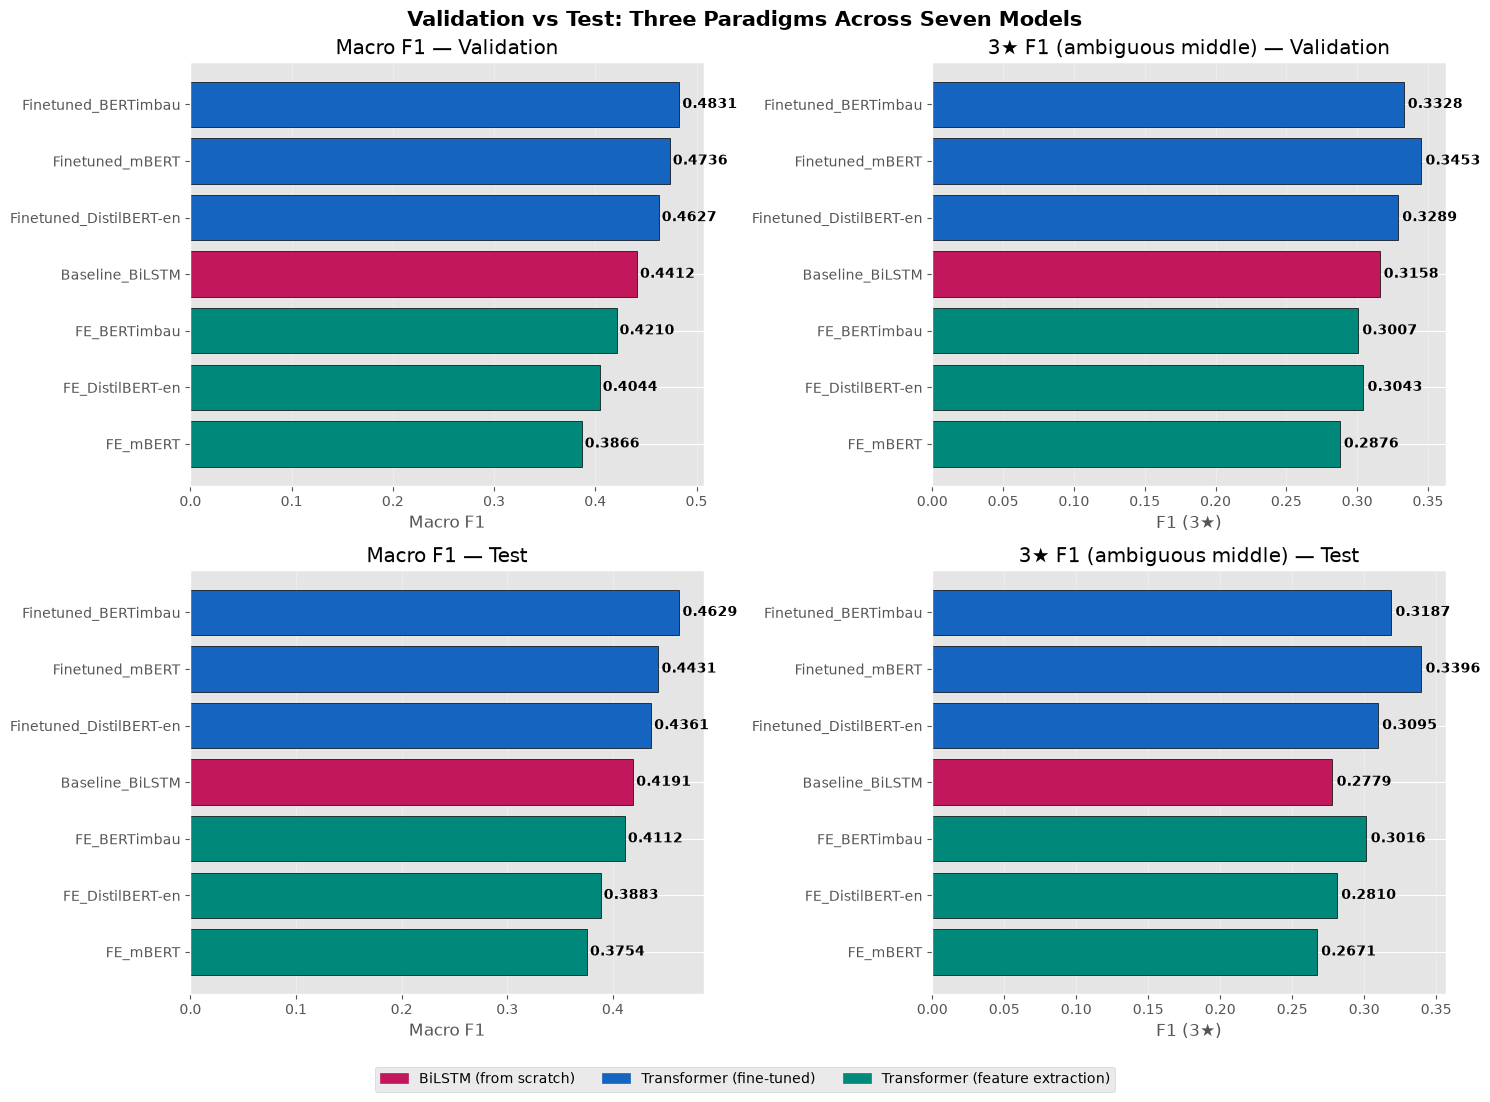

In [38]:
PALETTE = {"baseline": "#c2185b", "finetune": "#1565c0", "feature_extraction": "#00897b"}

def phase_cols(prefix):
    return {
        "tags.mlflow.runName": "model",
        "tags.stage": "stage",
        f"metrics.{prefix}_macro_f1": "macro_f1",
        f"metrics.{prefix}_f1_class_3_stars": "f1_3★",
    }

frames = {}
for phase_name, prefix in [("Validation", "val"), ("Test", "test")]:
    sub = (
        runs_df.loc[mask, list(phase_cols(prefix))]
        .rename(columns=phase_cols(prefix))
        .sort_values("macro_f1")
        .reset_index(drop=True)
    )
    frames[phase_name] = sub

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

for row, (phase_name, sub) in enumerate(frames.items()):
    colors = [PALETTE.get(s, "#888888") for s in sub["stage"]]

    ax_f1 = axes[row][0]
    ax_f1.barh(sub["model"], sub["macro_f1"], color=colors, edgecolor="black")
    ax_f1.set(title=f"Macro F1 — {phase_name}", xlabel="Macro F1")
    for i, v in enumerate(sub["macro_f1"]):
        ax_f1.text(v + 0.003, i, f"{v:.4f}", va="center", fontweight="bold")
    ax_f1.grid(axis="x", alpha=0.3)

    ax_mid = axes[row][1]
    ax_mid.barh(sub["model"], sub["f1_3★"], color=colors, edgecolor="black")
    ax_mid.set(title=f"3★ F1 (ambiguous middle) — {phase_name}", xlabel="F1 (3★)")
    for i, v in enumerate(sub["f1_3★"]):
        ax_mid.text(v + 0.003, i, f"{v:.4f}", va="center", fontweight="bold")
    ax_mid.grid(axis="x", alpha=0.3)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#c2185b", "#1565c0", "#00897b"]]
fig.legend(handles, ["BiLSTM (from scratch)", "Transformer (fine-tuned)", "Transformer (feature extraction)"],
           loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Validation vs Test: Three Paradigms Across Seven Models", fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 5 Conclusion: Semantic Distance in Review Scores

The test set confirms every pattern the validation set suggested with unusual consistency: the ranking of all seven models is **identical across both phases**, without a single position swap. Each model loses roughly 0.01–0.03 Macro F1 moving from validation to test, exactly the modest optimism one expects from a set that guided selection, and the paradigms stay cleanly stratified: fine-tuned Transformers on top (0.4361–0.4629), the from-scratch BiLSTM in the middle (0.4191), and frozen feature extractors at the bottom (0.3754–0.4112).

**Fine-tuned BERTimbau is the best model overall**, reaching a test Macro F1 of 0.4629 against the BiLSTM baseline's 0.4191, a gain of about 10%. It also posts the best ordinal agreement of any model (QWK 0.7543 vs the baseline's 0.6793) and the lowest MAE (0.6774 vs 0.7887). Native Portuguese pre-training holds its edge on held-out data, ahead of multilingual mBERT (0.4431) and English DistilBERT (0.4361), though the margin over both remains slim enough to call it a mild rather than decisive advantage. Notably, the frozen-encoder ordering also survives: BERTimbau leads the feature-extraction group too (0.4112), reinforcing that its embeddings are the most linearly separable for this task even before any adaptation.

The three paradigms answer the question of *where* pre-trained knowledge helps. Feature extraction lands **below** the from-scratch BiLSTM on every metric, so general-purpose representations alone are not enough; the task genuinely requires adapting the encoder. But the gap between feature extraction and fine-tuning (~0.05) is larger than the gap between fine-tuning and the BiLSTM (~0.04), which locates the value precisely: most of what the Transformers contribute comes from *fine-tuning on our reviews*, not from what they already knew.

### The asymmetry of the scale

Everything above concerns aggregate performance. The project's opening question was different: **is the semantic gap between a 1★ and a 2★ the same as the gap between a 3★ and a 4★?** The answer, across seven models, three paradigms, three languages, and two evaluation sets, is an unambiguous **no** and the shape of that asymmetry is remarkably stable.

Per-class F1 on the test set tells the story. The 5★ class is identified best by every single model (0.5426–0.6592), 1★ comes second (0.4629–0.5569), and 3★ is worst without exception (0.2671–0.3396). No model, however pre-trained, breaks 0.34 on the middle class; no model falls below 0.54 on 5★. The mean error distance per class makes the same point in stars rather than F1: for the best model, a 3★ review is misplaced by 0.94 stars on average, while a 5★ review is misplaced by only 0.37. The middle of the scale carries roughly **two and a half times** the error of the positive pole.

There is a second asymmetry worth naming: the two poles are not equally distinct. 5★ is consistently easier than 1★ across all models, plausibly because enthusiasm has its own vocabulary, while 1★ and 2★ reviews are both complaints drawing on the same lexicon of disappointment. The confusion matrices bear this out: for fine-tuned BERTimbau, 95 of 322 true 1★ reviews are predicted 2★, and 126 of 322 true 4★ reviews are predicted 5★. The scale's edges bleed into their neighbours; its center bleeds in both directions at once.

Yet the models are far from ignorant of the ordering. Roughly 87% of the best model's test predictions land within a single star, and a QWK of 0.75 alongside an exact-match accuracy of only 0.47 says precisely this: **the sentiment gradient is captured; the boundaries are not.** The models know a review is negative-ish or positive-ish and reliably place it in the right neighbourhood — they simply cannot decide whether a lukewarm complaint deserves two stars or three.

### What this means

The consistency of this pattern is itself the finding. If the difficulty around 3★ were a modelling limitation, we would expect it to yield somewhere — to a bigger vocabulary, a tuned architecture, contextual embeddings, native-language pre-training, or a different transfer regime. It yielded to none of them. The most reasonable reading is that the ambiguity is **in the data**: moderate reviews express genuinely mixed sentiment, and the mapping from their text to a specific star count is weakly determined even for a human reader. Two customers writing near-identical lukewarm comments may rate three and four stars respectively, and no model can recover a distinction the writers themselves applied inconsistently. **The semantic distance between adjacent ratings, then, is not uniform. It is widest at the poles, where language is unambiguous, and narrows toward the center until adjacent classes effectively overlap.** 

### Limitations and directions

Three caveats bound these conclusions. First, all comparisons rest on single runs; the per-class differences between the three Transformers (0.01–0.02) sit within the run-to-run variance we observed directly when re-running fine-tuning, so only the paradigm-level gaps should be considered firm. Second, the dataset was downsampled to balance the five classes, which discards a large share of the original reviews and changes the base rates a deployed model would face. Third, our loss function treats the five classes as unordered categories, penalising a 1★↔5★ error exactly as much as a 3★↔4★ one, which, given everything above, is precisely the wrong assumption.

That last point is the most promising direction forward. Ordinal-aware objectives (CORAL, CORN) or a regression formulation with thresholding would align the training signal with the ordinal structure the QWK already shows the models partially grasp. Beyond that: parameter-efficient fine-tuning (LoRA) to reduce overfitting risk on a small corpus, mean-pooled rather than [CLS] embeddings for the feature-extraction branch, and — most directly aimed at the central question — a human-annotation study to measure how consistently people themselves map these reviews to stars. If human agreement in the 2–4★ range proves as low as our models' performance suggests, we will have measured not a ceiling of the models, but the ceiling of the task.